# Full Pipeline Reference -- Survival-Based ML for 10-Year Heart Attack/Stroke Risk

**What this notebook is:** a single, read-only, joined-together view of every stage's actual source code (`src/01_data_ingestion.py` through `src/09_build_dashboard.py`), each followed by the figures/tables that stage produced on its last real run on `main`.

**What this notebook is not:** an executable pipeline. Code cells below are pasted verbatim from the committed `.py` files for reading, not re-run here -- there is no kernel output, and no cell has been executed. Re-running Stage 6/8 for real (deep learning training, SHAP, LIME) is a long job and stays in its own script per CLAUDE.md §15.1. Images and tables below are the real artefacts already committed under `results/`, embedded directly (base64) so they render even if this file is opened outside the repo.

**Ethics statement:** only `data/cvd_synthetic_dataset_v0.2.csv` (Burns, Richardson and Driessens, 2024), a CC0-licensed fully synthetic dataset, was used anywhere in this project -- no real patient data at any stage (CLAUDE.md §0.1, §12).


---
## Stage 1 -- Data Ingestion

Loads the dataset, verifies it against the CLAUDE.md §3 schema, and profiles the missingness/censoring mechanisms named in CLAUDE.md §4. No figures or tables are persisted by this stage -- its output is a console profiling report.


In [ ]:
"""Stage 1 — data ingestion.

Loads the CVD synthetic dataset, verifies it matches the schema fixed in CLAUDE.md §3, and
profiles the missingness and censoring mechanisms named in CLAUDE.md §4. All mechanisms
(informative censoring, MCAR flips/drops, MAR FEV1 drops, deliberate noise/irrelevant
predictors) are documented in Burns, Richardson and Driessens (2024).
"""

import sys
from pathlib import Path

import pandas as pd

DATA_PATH = Path(__file__).resolve().parent.parent / "data" / "cvd_synthetic_dataset_v0.2.csv"

EXPECTED_ROW_COUNT = 100_000
EXPECTED_COLUMNS = [
    "patient_id",
    "gender",
    "age",
    "body_mass_index",
    "smoker",
    "systolic_blood_pressure",
    "hypertension_treated",
    "family_history_of_cardiovascular_disease",
    "atrial_fibrillation",
    "chronic_kidney_disease",
    "rheumatoid_arthritis",
    "diabetes",
    "chronic_obstructive_pulmonary_disorder",
    "forced_expiratory_volume_1",
    "time_to_event_or_censoring",
    "heart_attack_or_stroke_occurred",
]

# Expected MCAR/MAR drop probabilities per CLAUDE.md §4, used only as an honesty check against
# the actually observed rates in this specific draw of the synthetic dataset.
EXPECTED_DROP_RATES = {
    "systolic_blood_pressure": 0.10,
    "body_mass_index": 0.30,
    "forced_expiratory_volume_1_copd_pos": 0.05,
    "forced_expiratory_volume_1_copd_neg": 0.75,
}
RATE_TOLERANCE = 0.02


def load_and_verify(path: Path) -> pd.DataFrame:
    """Load the dataset and verify it matches CLAUDE.md §3. Stops rather than proceeding
    silently on any schema mismatch, per CLAUDE.md §3 and §14."""
    df = pd.read_csv(path)

    errors = []
    if df.shape[0] != EXPECTED_ROW_COUNT:
        errors.append(f"row count = {df.shape[0]}, expected {EXPECTED_ROW_COUNT}")
    if df.shape[1] != len(EXPECTED_COLUMNS):
        errors.append(f"column count = {df.shape[1]}, expected {len(EXPECTED_COLUMNS)}")
    if list(df.columns) != EXPECTED_COLUMNS:
        errors.append(f"column names/order do not match §3: got {list(df.columns)}")

    if errors:
        raise ValueError(
            "Dataset does not match CLAUDE.md §3 schema — stopping rather than proceeding:\n"
            + "\n".join(f"  - {e}" for e in errors)
        )

    print(f"[OK] Loaded {df.shape[0]:,} rows x {df.shape[1]} columns, schema matches §3.")
    return df


def profile_missingness(df: pd.DataFrame) -> None:
    """Profile each MCAR/MAR mechanism named in CLAUDE.md §4, individually and by name —
    not a generic df.isnull().sum() dump."""
    print("\n--- Missingness profile (CLAUDE.md §4) ---")

    # MCAR: smoker and family_history are silently flipped 1->0 (p=0.30), not set to NaN, so
    # this mechanism leaves no missing-value trace in the loaded data and cannot be measured
    # empirically here. Documented as a known, non-recoverable limitation for those two columns.
    for col in ["smoker", "family_history_of_cardiovascular_disease"]:
        n_null = df[col].isnull().sum()
        print(
            f"  {col}: MCAR 1->0 flip (p=0.30, unobservable in the data itself). "
            f"NaN count = {n_null} (expected 0, since flips are silent, not deletions)."
        )

    # MCAR: systolic_blood_pressure and body_mass_index are dropped to NaN outright.
    for col, key in [
        ("systolic_blood_pressure", "systolic_blood_pressure"),
        ("body_mass_index", "body_mass_index"),
    ]:
        observed = df[col].isnull().mean()
        expected = EXPECTED_DROP_RATES[key]
        flag = "" if abs(observed - expected) <= RATE_TOLERANCE else "  <-- ANOMALY, see §0.7"
        print(f"  {col}: MCAR drop, observed rate = {observed:.4f} (expected ~{expected}){flag}")

    # MAR: forced_expiratory_volume_1 dropped conditionally on COPD status.
    fev1_by_copd = df.groupby("chronic_obstructive_pulmonary_disorder")[
        "forced_expiratory_volume_1"
    ].apply(lambda s: s.isnull().mean())
    for copd_status, key in [(1, "forced_expiratory_volume_1_copd_pos"),
                              (0, "forced_expiratory_volume_1_copd_neg")]:
        observed = fev1_by_copd.get(copd_status, float("nan"))
        expected = EXPECTED_DROP_RATES[key]
        flag = "" if abs(observed - expected) <= RATE_TOLERANCE else "  <-- ANOMALY, see §0.7"
        print(
            f"  forced_expiratory_volume_1 | COPD={copd_status}: observed rate = "
            f"{observed:.4f} (expected ~{expected}){flag}"
        )


def profile_censoring(df: pd.DataFrame) -> None:
    """Profile the informative right-censoring mechanism named in CLAUDE.md §4: dropout
    probability scales with time-to-event (Burns, Richardson and Driessens, 2024). This is
    exactly why downstream evaluation must use IPCW-weighted estimators (Uno's C-statistic,
    integrated Brier score, per §8) rather than treating censoring as uninformative."""
    print("\n--- Censoring profile (CLAUDE.md §4) ---")

    event_rate = df["heart_attack_or_stroke_occurred"].mean()
    admin_censored = ((df["heart_attack_or_stroke_occurred"] == 0)
                       & (df["time_to_event_or_censoring"] == 10)).mean()
    early_censored = ((df["heart_attack_or_stroke_occurred"] == 0)
                       & (df["time_to_event_or_censoring"] < 10)).mean()

    print(f"  Event rate (heart attack/stroke within 10y): {event_rate:.4f}")
    print(f"  Administratively censored at year 10 (study end): {admin_censored:.4f}")
    print(f"  Censored before year 10 (informative dropout): {early_censored:.4f}")
    print(
        "  NOTE: dropout-before-year-10 is the informative-censoring component — its rate "
        "scaling with time-to-event is a property of the data-generating process, not a "
        "processing artefact. Must be handled with IPCW-weighted C-index/Brier score at §8."
    )


def profile_noise_note() -> None:
    """CLAUDE.md §4: the release paper states the dataset deliberately includes variables that
    did not significantly contribute to the analyses, incorporating irrelevance and noise
    (Burns, Richardson and Driessens, 2024, p. 3). Which predictors are informative is not
    determined here — that is the explicit purpose of the Stage 2 feature-selection pipeline
    (§5), not an ingestion-time judgement call."""
    print("\n--- Noise/irrelevance note (CLAUDE.md §4) ---")
    print(
        "  Not all 14 predictors are assumed informative by design (Burns, Richardson and "
        "Driessens, 2024). Feature relevance is determined in Stage 2 (§5: multicollinearity "
        "screening + per-sex LASSO), not assumed here."
    )


def main() -> None:
    try:
        df = load_and_verify(DATA_PATH)
    except ValueError as e:
        print(f"[STOP] {e}", file=sys.stderr)
        sys.exit(1)

    profile_missingness(df)
    profile_censoring(df)
    profile_noise_note()

    print("\n[OK] Stage 1 complete: dataset verified, missingness and censoring profiled.")


if __name__ == "__main__":
    main()


---
## Stage 2 -- Preprocessing

Imputation (median/flag for MCAR, COPD-stratified median for MAR FEV1), encoding, and the sex-specific 70/15/15 split (CLAUDE.md §4/§6). No figures or standalone tables -- output is the split, in-memory per-sex dataframes consumed by every later stage.


In [ ]:
"""Stage 2 — preprocessing: imputation, encoding, sex-specific 70/15/15 split.

Follows CLAUDE.md §4 (imputation), §0.4 (sex-stratified pipelines — applied here to
imputation, not just modelling), and §6 (train/validation/test split). Missingness and split
design are grounded in Burns, Richardson and Driessens (2024) and Liu et al. (2026).

Two decisions here are explicit deviations from a literal reading of the spec, made with the
user's sign-off on 2026-08-20 (recorded in journal/agent_journal.md, per CLAUDE.md §14):

1. `smoker` and `family_history_of_cardiovascular_disease` are left completely untouched.
   §4 asks for an "unknown" category for these two flipped binary variables, but Stage 1
   confirmed the 1->0 flip (p=0.30) leaves no missing-value marker at all in the released
   CSV — every value is already a plain 0/1 with no way to tell a corrupted 0 from a true
   one. There is nothing to impute or flag. Both columns are documented as carrying known
   non-differential measurement error at p=0.30, not treated as missing data.
2. Imputation is computed and applied on the whole per-sex cohort *before* the 70/15/15
   split (matching §11's literal script description), not from the training fold only. This
   is a minor, acknowledged information leak from validation/test into the imputed median —
   negligible for a low-capacity statistic like a median, but flagged here since §5/§6 are
   strict about zero leakage elsewhere in the pipeline.
"""

import sys
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path(__file__).resolve().parent.parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "cvd_synthetic_dataset_v0.2.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

EXPECTED_ROW_COUNT = 100_000
EXPECTED_COLUMNS = [
    "patient_id", "gender", "age", "body_mass_index", "smoker", "systolic_blood_pressure",
    "hypertension_treated", "family_history_of_cardiovascular_disease", "atrial_fibrillation",
    "chronic_kidney_disease", "rheumatoid_arthritis", "diabetes",
    "chronic_obstructive_pulmonary_disorder", "forced_expiratory_volume_1",
    "time_to_event_or_censoring", "heart_attack_or_stroke_occurred",
]

RANDOM_STATE = 42
EVENT_COL = "heart_attack_or_stroke_occurred"


def load_and_verify(path: Path) -> pd.DataFrame:
    """Same §3 schema check as Stage 1 — kept self-contained here so each stage script can be
    run independently (§2: one script per pipeline stage)."""
    df = pd.read_csv(path)
    errors = []
    if df.shape[0] != EXPECTED_ROW_COUNT:
        errors.append(f"row count = {df.shape[0]}, expected {EXPECTED_ROW_COUNT}")
    if list(df.columns) != EXPECTED_COLUMNS:
        errors.append(f"column names/order do not match §3: got {list(df.columns)}")
    if errors:
        raise ValueError(
            "Dataset does not match CLAUDE.md §3 schema — stopping rather than proceeding:\n"
            + "\n".join(f"  - {e}" for e in errors)
        )
    return df


def impute_sex_cohort(cohort: pd.DataFrame, sex_label: str) -> pd.DataFrame:
    """Impute one sex cohort's missing values per §4, using statistics from that cohort only
    (§0.4's two-fully-independent-pipelines principle applied to preprocessing)."""
    cohort = cohort.copy()

    for col in ["body_mass_index", "systolic_blood_pressure"]:
        median = cohort[col].median()
        n_missing = cohort[col].isnull().sum()
        cohort[col] = cohort[col].fillna(median)
        print(f"  [{sex_label}] {col}: filled {n_missing} missing with median = {median:.2f}")

    # MAR: FEV1 imputed conditionally within COPD strata, never with a single unconditional
    # median (CLAUDE.md §4).
    for copd_status in [0, 1]:
        mask = cohort["chronic_obstructive_pulmonary_disorder"] == copd_status
        median = cohort.loc[mask, "forced_expiratory_volume_1"].median()
        n_missing = cohort.loc[mask, "forced_expiratory_volume_1"].isnull().sum()
        cohort.loc[mask, "forced_expiratory_volume_1"] = cohort.loc[
            mask, "forced_expiratory_volume_1"
        ].fillna(median)
        print(
            f"  [{sex_label}] forced_expiratory_volume_1 | COPD={copd_status}: filled "
            f"{n_missing} missing with median = {median:.2f}"
        )

    # smoker / family_history_of_cardiovascular_disease: intentionally left untouched — see
    # module docstring point 1.
    print(
        f"  [{sex_label}] smoker, family_history_of_cardiovascular_disease: left as-is "
        f"(non-differential measurement error, p=0.30 — no missing-value marker exists)."
    )
    return cohort


def encoding_note(df: pd.DataFrame) -> None:
    """§11 lists 'encoding' as part of this stage. Documented explicitly rather than silently
    skipped: no categorical encoding is required. All 14 predictors besides `gender` are
    already numeric (int/0-1 binary). `gender` itself is used only to split into the two
    sex-specific cohorts (§0.4) — it is never a covariate in either pipeline, so it is not
    encoded as a feature."""
    non_numeric = [c for c in df.columns if c not in ("patient_id", "gender")
                   and df[c].dtype == object]
    assert not non_numeric, f"unexpected non-numeric predictor columns: {non_numeric}"
    print("  All predictors besides `gender` are already numeric — no encoding required.")
    print("  `gender` is used only to split cohorts, never as a covariate (§0.4).")


def sex_stratified_split(cohort: pd.DataFrame, sex_label: str):
    """§6: 70/15/15 split, stratified on the event indicator, random_state=42, independent
    per sex cohort."""
    train, temp = train_test_split(
        cohort, test_size=0.30, stratify=cohort[EVENT_COL], random_state=RANDOM_STATE
    )
    val, test = train_test_split(
        temp, test_size=0.50, stratify=temp[EVENT_COL], random_state=RANDOM_STATE
    )

    n = len(cohort)
    print(
        f"  [{sex_label}] split: train={len(train)} ({len(train)/n:.1%}), "
        f"val={len(val)} ({len(val)/n:.1%}), test={len(test)} ({len(test)/n:.1%})"
    )
    for name, part in [("train", train), ("val", val), ("test", test)]:
        print(f"  [{sex_label}] {name} event rate = {part[EVENT_COL].mean():.4f}")

    return train, val, test


def run_sanity_checks(cohort: pd.DataFrame, train, val, test, sex_label: str) -> None:
    """§10.4 test/sanity check: split sizes reconstruct the cohort exactly, no patient
    appears in more than one partition, and event rate is preserved within a small tolerance
    (stratified split, so should be very close)."""
    assert len(train) + len(val) + len(test) == len(cohort), (
        f"[{sex_label}] split sizes don't sum to cohort size"
    )
    ids = pd.concat([train["patient_id"], val["patient_id"], test["patient_id"]])
    assert ids.is_unique, f"[{sex_label}] a patient_id appears in more than one split"
    assert not train[["body_mass_index", "systolic_blood_pressure",
                       "forced_expiratory_volume_1"]].isnull().any().any(), (
        f"[{sex_label}] imputation left residual NaNs in train"
    )

    full_rate = cohort[EVENT_COL].mean()
    for name, part in [("train", train), ("val", val), ("test", test)]:
        rate = part[EVENT_COL].mean()
        assert abs(rate - full_rate) < 0.01, (
            f"[{sex_label}] {name} event rate {rate:.4f} deviates >1pp from cohort rate "
            f"{full_rate:.4f}"
        )
    print(f"  [{sex_label}] sanity checks passed: sizes reconcile, no ID overlap, "
          f"no residual NaNs in imputed columns, event rate preserved within 1pp.")


def main() -> None:
    try:
        df = load_and_verify(RAW_DATA_PATH)
    except ValueError as e:
        print(f"[STOP] {e}", file=sys.stderr)
        sys.exit(1)
    print(f"[OK] Loaded {df.shape[0]:,} rows, schema matches §3.")

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    print("\n--- Encoding (§11) ---")
    encoding_note(df)

    for sex_code, sex_label in [("M", "male"), ("F", "female")]:
        print(f"\n--- {sex_label.capitalize()} cohort ---")
        cohort = df[df["gender"] == sex_code].reset_index(drop=True)
        print(f"  n = {len(cohort)}")

        cohort = impute_sex_cohort(cohort, sex_label)
        train, val, test = sex_stratified_split(cohort, sex_label)
        run_sanity_checks(cohort, train, val, test, sex_label)

        for name, part in [("train", train), ("val", val), ("test", test)]:
            out_path = PROCESSED_DIR / f"{sex_label}_{name}.csv"
            part.to_csv(out_path, index=False)
        print(f"  [{sex_label}] wrote train/val/test CSVs to {PROCESSED_DIR}")

    print("\n[OK] Stage 2 complete: imputed, encoded, and split both sex cohorts.")


if __name__ == "__main__":
    main()


---
## Stage 3 -- Feature Selection

Multicollinearity screening, per-sex LASSO, QRISK3 cross-reference (CLAUDE.md §5). Writes `results/tables/stage3_feature_selection_{sex}.csv`.


In [ ]:
"""Stage 3 — feature selection (CLAUDE.md §5): multicollinearity screening, per-sex LASSO,
QRISK3 cross-reference. Run independently per sex, training-fold only for fitting, validation
fold only for tuning — never test data.

**Predictor-count discrepancy, flagged and resolved with the user on 2026-08-20 (§14):**
CLAUDE.md repeatedly says "14 predictors" (§4, §5.1), but the dataset only has 12 columns
usable as survival-model predictors — the "14" figure only works by also counting
`time_to_event_or_censoring` and `heart_attack_or_stroke_occurred` (the survival outcome
itself) as if they were predictors. Treated here as a spec wording slip; feature selection
runs on the 12 actual clinical/physiological columns.

LASSO: L1-penalised Cox partial-likelihood LASSO (Tibshirani, 1996), fitted via
`sksurv.linear_model.CoxnetSurvivalAnalysis` (Pölsterl, 2020) with `l1_ratio=1.0` for pure L1.
QRISK3 cross-reference set is the simplified rebuild's predictor list from CLAUDE.md §7,
itself derived from Hippisley-Cox, Coupland and Brindle (2017).
"""

import sys
from pathlib import Path

import pandas as pd
from scipy.stats import pearsonr, pointbiserialr
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

PROJECT_ROOT = Path(__file__).resolve().parent.parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "cvd_synthetic_dataset_v0.2.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "tables"

SEX_CODE = {"male": "M", "female": "F"}

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"

# The 12 predictors actually usable for survival modelling — patient_id (identifier), gender
# (used only to stratify cohorts, §0.4), and the two outcome columns are excluded. See module
# docstring re: the "14 predictors" spec discrepancy.
CONTINUOUS = ["age", "body_mass_index", "systolic_blood_pressure", "forced_expiratory_volume_1"]
BINARY = [
    "smoker", "hypertension_treated", "family_history_of_cardiovascular_disease",
    "atrial_fibrillation", "chronic_kidney_disease", "rheumatoid_arthritis", "diabetes",
    "chronic_obstructive_pulmonary_disorder",
]
PREDICTORS = CONTINUOUS + BINARY

# Predictors present in this project's simplified QRISK3-style rebuild (CLAUDE.md §7), used
# as the multicollinearity tie-break and the §5.3 cross-reference set. COPD and FEV1 are the
# two columns in this dataset that are *not* part of QRISK3's original predictor set
# (Hippisley-Cox, Coupland and Brindle, 2017) — they are the deliberate noise/extra variables
# named in §4.
QRISK3_BASIS = {
    "age", "smoker", "systolic_blood_pressure", "diabetes",
    "family_history_of_cardiovascular_disease", "chronic_kidney_disease",
    "rheumatoid_arthritis", "hypertension_treated", "atrial_fibrillation", "body_mass_index",
}

CORRELATION_THRESHOLD = 0.80
RANDOM_STATE = 42


def load_split(sex_label: str, part: str) -> pd.DataFrame:
    path = PROCESSED_DIR / f"{sex_label}_{part}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/02_preprocessing.py first.")
    return pd.read_csv(path)


def load_raw_missingness(sex_label: str) -> pd.DataFrame:
    """Raw (pre-Stage-2-imputation) missingness mask per patient, keyed by patient_id. Used
    only by the complete-case tie-break below — needed to tell whether an over-threshold
    correlation involving a continuous, imputed predictor reflects real clinical redundancy
    or is partly inflated by Stage 2's conditional-median imputation."""
    raw = pd.read_csv(RAW_DATA_PATH)
    raw = raw[raw["gender"] == SEX_CODE[sex_label]]
    return raw.set_index("patient_id")[CONTINUOUS].isnull()


def resolve_tie_by_complete_case_correlation(a: str, b: str, full_r: float,
                                              train_df: pd.DataFrame, raw_missing: pd.DataFrame,
                                              sex_label: str) -> str:
    """User-specified tie-break (2026-08-20) for pairs where neither member has a QRISK3
    basis to break the tie: recompute the correlation restricted to training rows where the
    continuous member's raw value was NOT imputed (complete cases only). If that complete-case
    r is still >= the threshold, the redundancy is judged real, and the coarser binary member
    is dropped in favour of the more information-rich continuous one. If it drops meaningfully
    below the threshold, the full-sample correlation is judged to be substantially an artefact
    of the conditional-median imputation, and the continuous member is dropped instead."""
    assert (a in CONTINUOUS) != (b in CONTINUOUS), (
        f"complete-case tie-break only implemented for one-continuous/one-binary pairs, "
        f"got {a} vs {b}"
    )
    continuous_var = a if a in CONTINUOUS else b
    binary_var = b if a in CONTINUOUS else a

    missing_lookup = raw_missing[continuous_var].reindex(train_df["patient_id"]).to_numpy()
    complete_case = train_df.loc[~missing_lookup]
    n_excluded = int(missing_lookup.sum())
    cc_r, _ = pointbiserialr(complete_case[binary_var], complete_case[continuous_var])

    print(
        f"  [{sex_label}] AMBIGUOUS redundancy: {a} vs {b} (full-sample r={full_r:.3f}) — "
        f"neither has a QRISK3 tie-break. Complete-case r (excluding {n_excluded} rows where "
        f"{continuous_var} was imputed) = {cc_r:.3f}."
    )
    if abs(cc_r) >= CORRELATION_THRESHOLD:
        drop, keep = binary_var, continuous_var
        reason = (f"complete-case r={cc_r:.3f} still >= {CORRELATION_THRESHOLD} — redundancy "
                  f"confirmed real; keeping the more information-rich continuous variable")
    else:
        drop, keep = continuous_var, binary_var
        reason = (f"complete-case r={cc_r:.3f} drops below {CORRELATION_THRESHOLD} — "
                  f"full-sample correlation was inflated by imputation; keeping the complete "
                  f"binary variable instead")
    print(f"  [{sex_label}] tie-break: dropping {drop}, keeping {keep} ({reason}).")
    return drop


def screen_multicollinearity(train_df: pd.DataFrame, raw_missing: pd.DataFrame, sex_label: str):
    """§5.1: Pearson (continuous-continuous) and point-biserial (continuous-binary)
    correlation screening on the training fold only. Flags |r| > 0.80 as redundant and drops
    the member with weaker QRISK3 clinical basis (§7). Ties (both or neither in the QRISK3
    basis) fall back to the complete-case correlation tie-break above, per the user's
    2026-08-20 instruction — not silently reconciled by any default rule."""
    rows = []
    for i, a in enumerate(CONTINUOUS):
        for b in CONTINUOUS[i + 1:]:
            r, _ = pearsonr(train_df[a], train_df[b])
            rows.append((a, b, "pearson", r))
    for a in CONTINUOUS:
        for b in BINARY:
            r, _ = pointbiserialr(train_df[b], train_df[a])
            rows.append((a, b, "point-biserial", r))
    corr_df = pd.DataFrame(rows, columns=["var_a", "var_b", "method", "r"])

    dropped = []
    flagged = corr_df[corr_df["r"].abs() > CORRELATION_THRESHOLD]
    for _, row in flagged.iterrows():
        a, b, r = row["var_a"], row["var_b"], row["r"]
        a_in, b_in = a in QRISK3_BASIS, b in QRISK3_BASIS
        if a_in and not b_in:
            drop, keep = b, a
            print(f"  [{sex_label}] redundant pair {a} vs {b} (r={r:.3f}) — dropping {drop} "
                  f"(weaker QRISK3 basis), keeping {keep}.")
        elif b_in and not a_in:
            drop, keep = a, b
            print(f"  [{sex_label}] redundant pair {a} vs {b} (r={r:.3f}) — dropping {drop} "
                  f"(weaker QRISK3 basis), keeping {keep}.")
        else:
            drop = resolve_tie_by_complete_case_correlation(
                a, b, r, train_df, raw_missing, sex_label
            )
        dropped.append(drop)

    if not flagged.shape[0]:
        print(f"  [{sex_label}] no predictor pairs exceed |r| > {CORRELATION_THRESHOLD} — "
              f"no multicollinearity redundancy found.")

    return sorted(set(dropped)), corr_df


def select_lasso_features(train_df: pd.DataFrame, val_df: pd.DataFrame, candidates: list,
                           sex_label: str):
    """§5.2: L1-penalised Cox partial-likelihood LASSO (Tibshirani, 1996), fitted on the
    training fold, penalty strength tuned on the validation fold by C-index — never the
    training set, never the test set."""
    X_train = train_df[candidates].astype(float)
    y_train = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    X_val = val_df[candidates].astype(float)
    y_val = Surv.from_dataframe(EVENT_COL, TIME_COL, val_df)

    model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01, normalize=True)
    model.fit(X_train, y_train)

    best_alpha, best_cindex = None, -1.0
    for alpha in model.alphas_:
        risk_scores = model.predict(X_val, alpha=alpha)
        cindex = concordance_index_censored(
            y_val[EVENT_COL], y_val[TIME_COL], risk_scores
        )[0]
        if cindex > best_cindex:
            best_alpha, best_cindex = alpha, cindex

    coefs = pd.Series(
        model.coef_[:, list(model.alphas_).index(best_alpha)], index=candidates
    )
    selected = sorted(coefs[coefs != 0].index.tolist())

    print(f"  [{sex_label}] LASSO: best alpha = {best_alpha:.5f} (val C-index = "
          f"{best_cindex:.4f}), {len(selected)}/{len(candidates)} predictors survive.")
    return selected, coefs, best_alpha, best_cindex


def cross_reference_qrisk3(selected: list, candidates: list, sex_label: str):
    """§5.3: flag disagreements between the LASSO-surviving set and the QRISK3 predictor set
    explicitly — not silently reconciled."""
    disagreements = []
    for p in candidates:
        lasso_keeps = p in selected
        qrisk3_keeps = p in QRISK3_BASIS
        if lasso_keeps != qrisk3_keeps:
            disagreements.append(p)
            print(f"  [{sex_label}] DISAGREEMENT: {p} — LASSO "
                  f"{'keeps' if lasso_keeps else 'drops'}, QRISK3 basis "
                  f"{'includes' if qrisk3_keeps else 'excludes'} it.")
    if not disagreements:
        print(f"  [{sex_label}] no LASSO/QRISK3 disagreements.")
    return disagreements


def run_sex_pipeline(sex_label: str) -> pd.DataFrame:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    train_df = load_split(sex_label, "train")
    val_df = load_split(sex_label, "val")
    raw_missing = load_raw_missingness(sex_label)

    dropped_by_corr, corr_df = screen_multicollinearity(train_df, raw_missing, sex_label)
    candidates = [p for p in PREDICTORS if p not in dropped_by_corr]

    selected, coefs, best_alpha, best_cindex = select_lasso_features(
        train_df, val_df, candidates, sex_label
    )
    disagreements = cross_reference_qrisk3(selected, candidates, sex_label)

    summary = pd.DataFrame({"predictor": PREDICTORS})
    summary["dropped_by_multicollinearity"] = summary["predictor"].isin(dropped_by_corr)
    summary["lasso_coefficient"] = summary["predictor"].map(coefs)
    summary["selected_by_lasso"] = summary["predictor"].isin(selected)
    summary["in_qrisk3_basis"] = summary["predictor"].isin(QRISK3_BASIS)
    summary["lasso_qrisk3_disagreement"] = summary["predictor"].isin(disagreements)
    summary["final_selected_feature_set"] = summary["selected_by_lasso"]

    assert not summary.loc[summary["dropped_by_multicollinearity"], "final_selected_feature_set"].any(), (
        f"[{sex_label}] a multicollinearity-dropped predictor leaked into the final set"
    )
    assert summary["final_selected_feature_set"].sum() > 0, (
        f"[{sex_label}] LASSO selected zero features — degenerate result"
    )

    out_path = RESULTS_DIR / f"stage3_feature_selection_{sex_label}.csv"
    summary.to_csv(out_path, index=False)
    print(f"  [{sex_label}] wrote {out_path}")
    return summary


def main() -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for sex_label in ["male", "female"]:
        try:
            run_sex_pipeline(sex_label)
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)
    print("\n[OK] Stage 3 complete: multicollinearity screened, LASSO-selected, "
          "QRISK3-cross-referenced for both sexes.")


if __name__ == "__main__":
    main()


**Feature selection outcome -- male cohort**

| predictor | dropped_by_multicollinearity | lasso_coefficient | selected_by_lasso | in_qrisk3_basis | lasso_qrisk3_disagreement | final_selected_feature_set |
| --- | --- | --- | --- | --- | --- | --- |
| age | False | 0.0655 | True | True | False | True |
| body_mass_index | False | 0.0000 | False | True | True | False |
| systolic_blood_pressure | False | 0.0073 | True | True | False | True |
| forced_expiratory_volume_1 | True | nan | False | False | False | False |
| smoker | False | 0.2153 | True | True | False | True |
| hypertension_treated | False | 0.1347 | True | True | False | True |
| family_history_of_cardiovascular_disease | False | 0.1329 | True | True | False | True |
| atrial_fibrillation | False | 0.2893 | True | True | False | True |
| chronic_kidney_disease | False | 0.1102 | True | True | False | True |
| rheumatoid_arthritis | False | 0.0152 | True | True | False | True |
| diabetes | False | 0.4981 | True | True | False | True |
| chronic_obstructive_pulmonary_disorder | False | 0.0000 | False | False | False | False |



**Feature selection outcome -- female cohort**

| predictor | dropped_by_multicollinearity | lasso_coefficient | selected_by_lasso | in_qrisk3_basis | lasso_qrisk3_disagreement | final_selected_feature_set |
| --- | --- | --- | --- | --- | --- | --- |
| age | False | 0.0743 | True | True | False | True |
| body_mass_index | False | 0.0000 | False | True | True | False |
| systolic_blood_pressure | False | 0.0075 | True | True | False | True |
| forced_expiratory_volume_1 | True | nan | False | False | False | False |
| smoker | False | 0.2226 | True | True | False | True |
| hypertension_treated | False | 0.2111 | True | True | False | True |
| family_history_of_cardiovascular_disease | False | 0.1227 | True | True | False | True |
| atrial_fibrillation | False | 0.7347 | True | True | False | True |
| chronic_kidney_disease | False | 0.1307 | True | True | False | True |
| rheumatoid_arthritis | False | 0.0767 | True | True | False | True |
| diabetes | False | 0.5452 | True | True | False | True |
| chronic_obstructive_pulmonary_disorder | False | -0.0552 | True | False | True | True |



---
## Stage 4 -- Baselines (Kaplan-Meier, CoxPH, QRISK3-style)

Fits the descriptive KM curves plus the CoxPH and QRISK3-style baselines per sex (CLAUDE.md §7). Predictions are persisted for Stage 7 to score uniformly; KM curves are saved as figures here.


In [ ]:
"""Stage 4 — baselines (CLAUDE.md §7): Kaplan-Meier (descriptive), CoxPH, and the simplified
QRISK3-style score rebuild. Per sex. Fits/builds the baseline models and persists per-patient
risk predictions to `results/tables/` for Stage 5/§11 (07_evaluation.py) to score uniformly
alongside RSF/GBSA/DeepSurv/DeepHit — C-index, Uno's C, Brier score, calibration, and
bootstrap 95% CIs (§8, §12) are computed there, not here, so every model is scored the same
way. KM curves are saved to `results/figures/`.

**QRISK3 coefficient provenance — flagged to and resolved with the user on 2026-08-20 (§14):**
CLAUDE.md §7 asks for "the exact simplified variant Burns, Richardson and Driessens (2024)
used to simulate the outcome." Their paper (checked directly, plus the Zenodo deposit — no
supplementary code or coefficients exist anywhere) only describes their approach
qualitatively; the actual per-predictor coefficients they used are not published and are
unrecoverable. Per the user's instruction, this rebuild instead uses the real, original
QRISK3-2017 coefficients (Hippisley-Cox, Coupland and Brindle, 2017), sourced from ClinRisk
Ltd.'s own reference implementation (released under LGPL specifically "to enable others to
implement the algorithm faithfully," https://qrisk.org, mirrored at
https://github.com/sisuhealthgroup/qrisk3/blob/master/src/lib/original/qrisk3.c) and
restricted to this dataset's available predictors per §7's rules. This Python port was
validated against ClinRisk's own published test cases (age x sex x cholesterol/HDL grid,
white ethnicity, no comorbidities) before being restricted — all 8 cases matched to within
0.05 percentage points. Corroborating evidence this is a reasonable proxy for what Burns et
al. actually did: their paper's stated 10-year baseline survival values (0.977 male / 0.989
female) match the real QRISK3 baseline survivor constants (0.977268... / 0.988876...) to 3
decimal places — they evidently anchored their simulation on the same baseline hazard.
"""

import math
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"
SPLITS = ["train", "val", "test"]
HORIZON_YEARS = 10.0
# Integer years 1-10 — matches the dataset's own time resolution (time_to_event_or_censoring
# is integer-valued) and the grid DeepHit uses internally (Stage 6). Needed for Stage 7's
# integrated Brier score, which requires survival probabilities across a range, not one point.
EVAL_TIME_GRID = list(range(1, 11))


# --- QRISK3-style score (§7) --------------------------------------------------------------
# Coefficients are the real QRISK3-2017 values (Hippisley-Cox, Coupland and Brindle, 2017),
# restricted to this dataset's predictors. Ethnicity and Townsend deprivation terms (absent
# from this dataset, §7) are omitted entirely, not defaulted to a "neutral" value, since a
# defaulted raw value would still contribute a non-zero centred term. rati (cholesterol/HDL)
# and sbps5 (SBP SD) are retained but fixed at 3 and 10 respectively, per §7.
QRISK3_SURVIVOR_10Y = {"female": 0.988876402378082, "male": 0.977268040180206}
QRISK3_ISMOKE_LIGHT = {"female": 0.13386833786546262, "male": 0.19128222863388983}
FIXED_CHOLESTEROL_HDL_RATIO = 3.0
FIXED_SBP_SD = 10.0

# Known, accepted behaviour (user sign-off 2026-08-20, §0.7 — not silently smoothed over):
# QRISK3 is only officially validated for ages 25-84. 11.1% of this dataset (11,110 patients)
# is under 25, and the fractional-polynomial age/BMI terms below are not calibrated for that
# range. For the rare combination of very young age with the dataset's implausible synthetic
# BMI floor (values down to 6, no lower bound), those terms compound into a very large linear
# predictor, and the survival exponentiation saturates the score at exactly 100.0 — 13
# patients total (0.013% of the dataset) are affected. Left unclipped and unexcluded
# deliberately: no clip threshold is specified anywhere in the source material, and excluding
# these patients would make the QRISK3-style baseline cover a different population than the
# other five models. See journal/agent_journal.md for the full account.


def qrisk3_style_score(row: pd.Series, sex_label: str) -> float:
    age_scaled = row["age"] / 10.0
    bmi_scaled = row["body_mass_index"] / 10.0
    sbp = row["systolic_blood_pressure"]
    smoke_light = 1 if row["smoker"] == 1 else 0  # §7: smoker ≈ light-smoker status
    diabetes_type2 = 1 if row["diabetes"] == 1 else 0  # §7: diabetes ≈ type 2

    if sex_label == "female":
        age_1, age_2 = age_scaled ** -2, age_scaled
        age_1 -= 0.053274843841791
        age_2 -= 4.332503318786621
        bmi_1, bmi_2 = bmi_scaled ** -2, (bmi_scaled ** -2) * math.log(bmi_scaled)
        bmi_1 -= 0.154946178197861
        bmi_2 -= 0.144462317228317
        rati = FIXED_CHOLESTEROL_HDL_RATIO - 3.476326465606690
        sbp_c = sbp - 123.130012512207030
        sbps5 = FIXED_SBP_SD - 9.002537727355957

        a = QRISK3_ISMOKE_LIGHT["female"] * smoke_light
        a += age_1 * -8.1388109247726188 + age_2 * 0.79733376689699098
        a += bmi_1 * 0.29236092275460052 + bmi_2 * -4.1513300213837665
        a += rati * 0.15338035820802554 + sbp_c * 0.013131488407103424
        a += sbps5 * 0.0078894541014586095
        a += row["atrial_fibrillation"] * 1.5923354969269663
        a += row["rheumatoid_arthritis"] * 0.21364803435181942
        a += row["chronic_kidney_disease"] * 0.65194569493845833
        a += row["hypertension_treated"] * 0.50931593683423004
        a += diabetes_type2 * 1.0688773244615468
        a += row["family_history_of_cardiovascular_disease"] * 0.45445319020896213
        a += age_1 * smoke_light * -4.7057161785851891
        a += age_1 * row["atrial_fibrillation"] * 19.938034889546561
        a += age_1 * row["chronic_kidney_disease"] * -3.5874047731694114
        a += age_1 * row["hypertension_treated"] * 11.872809733921812
        a += age_1 * diabetes_type2 * 6.8652342000009599
        a += age_1 * bmi_1 * 23.802623412141742 + age_1 * bmi_2 * -71.184947692087007
        a += age_1 * row["family_history_of_cardiovascular_disease"] * 0.99467807940435127
        a += age_1 * sbp_c * 0.034131842338615485
        a += age_2 * smoke_light * -0.075589244643193026
        a += age_2 * row["atrial_fibrillation"] * -0.076182651011162505
        a += age_2 * row["chronic_kidney_disease"] * -0.22688873086442507
        a += age_2 * row["hypertension_treated"] * 0.00096857823588174436
        a += age_2 * diabetes_type2 * -0.097112252590695489
        a += age_2 * bmi_1 * 0.52369958933664429 + age_2 * bmi_2 * 0.045744190122323759
        a += age_2 * row["family_history_of_cardiovascular_disease"] * -0.076885051698423038
        a += age_2 * sbp_c * -0.0015082501423272358
        survivor = QRISK3_SURVIVOR_10Y["female"]
    else:
        age_1, age_2 = age_scaled ** -1, age_scaled ** 3
        age_1 -= 0.234766781330109
        age_2 -= 77.284080505371094
        bmi_1, bmi_2 = bmi_scaled ** -2, (bmi_scaled ** -2) * math.log(bmi_scaled)
        bmi_1 -= 0.149176135659218
        bmi_2 -= 0.141913309693336
        rati = FIXED_CHOLESTEROL_HDL_RATIO - 4.300998687744141
        sbp_c = sbp - 128.571578979492190
        sbps5 = FIXED_SBP_SD - 8.756621360778809

        a = QRISK3_ISMOKE_LIGHT["male"] * smoke_light
        a += age_1 * -17.839781666005575 + age_2 * 0.0022964880605765492
        a += bmi_1 * 2.4562776660536358 + bmi_2 * -8.3011122314711354
        a += rati * 0.17340196856327111 + sbp_c * 0.012910126542553305
        a += sbps5 * 0.010251914291290456
        a += row["atrial_fibrillation"] * 0.88209236928054657
        a += row["rheumatoid_arthritis"] * 0.20970658013956567
        a += row["chronic_kidney_disease"] * 0.71853261288274384
        a += row["hypertension_treated"] * 0.51659871082695474
        a += diabetes_type2 * 0.85942071430932221
        a += row["family_history_of_cardiovascular_disease"] * 0.54055469009390156
        a += age_1 * smoke_light * -0.21011133933516346
        a += age_1 * row["atrial_fibrillation"] * 3.4896675530623207
        a += age_1 * row["chronic_kidney_disease"] * -0.50656716327223694
        a += age_1 * row["hypertension_treated"] * 6.5114581098532671
        a += age_1 * diabetes_type2 * 3.6461817406221311
        a += age_1 * bmi_1 * 31.004952956033886 + age_1 * bmi_2 * -111.29157184391643
        a += age_1 * row["family_history_of_cardiovascular_disease"] * 2.7808628508531887
        a += age_1 * sbp_c * 0.018858524469865853
        a += age_2 * smoke_light * -0.00049854870275326121
        a += age_2 * row["atrial_fibrillation"] * -0.00034995608340636049
        a += age_2 * row["chronic_kidney_disease"] * -0.0018325930166498813
        a += age_2 * row["hypertension_treated"] * 0.00063838053104165013
        a += age_2 * diabetes_type2 * -0.00024695695588868315
        a += age_2 * bmi_1 * 0.0050380102356322029 + age_2 * bmi_2 * -0.013074483002524319
        a += age_2 * row["family_history_of_cardiovascular_disease"] * -0.00024791809907396037
        a += age_2 * sbp_c * -0.0000127187419158845700
        survivor = QRISK3_SURVIVOR_10Y["male"]

    return 100.0 * (1 - survivor ** math.exp(a))


# --- Loading ---------------------------------------------------------------------------------

def load_split(sex_label: str, part: str) -> pd.DataFrame:
    path = PROCESSED_DIR / f"{sex_label}_{part}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/02_preprocessing.py first.")
    return pd.read_csv(path)


def load_selected_features(sex_label: str) -> list:
    path = RESULTS_TABLES / f"stage3_feature_selection_{sex_label}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/03_feature_selection.py first.")
    summary = pd.read_csv(path)
    return sorted(summary.loc[summary["final_selected_feature_set"], "predictor"].tolist())


# --- Kaplan-Meier (descriptive only, §7) ------------------------------------------------------

def plot_kaplan_meier(sex_label: str, full_cohort: pd.DataFrame) -> None:
    time, survival_prob, conf_int = kaplan_meier_estimator(
        full_cohort[EVENT_COL].astype(bool), full_cohort[TIME_COL], conf_type="log-log"
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.step(time, survival_prob, where="post", label=f"{sex_label} (n={len(full_cohort)})")
    ax.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
    ax.set_xlabel("Years")
    ax.set_ylabel("Survival probability (event-free)")
    ax.set_title(f"Kaplan-Meier — {sex_label} cohort (descriptive only)")
    ax.set_ylim(0, 1.02)
    ax.legend()
    fig.tight_layout()
    out_path = RESULTS_FIGURES / f"km_curve_{sex_label}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"  [{sex_label}] KM curve saved to {out_path} "
          f"(survival at 10y = {survival_prob[time <= 10][-1]:.4f})")


# --- CoxPH (§7) --------------------------------------------------------------------------------

def fit_coxph(train_df: pd.DataFrame, features: list, sex_label: str):
    X_train = train_df[features].astype(float)
    y_train = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    model = CoxPHSurvivalAnalysis()
    model.fit(X_train, y_train)
    print(f"  [{sex_label}] CoxPH fitted on {len(features)} Stage-3-selected features: "
          f"{features}")
    return model


def survival_at_horizon(model, X: pd.DataFrame, horizon: float = HORIZON_YEARS) -> np.ndarray:
    """§8: Brier score and calibration need a predicted P(event by horizon) = 1 - S(horizon|X)
    per patient, not just a relative risk score — the risk score alone is only sufficient for
    the C-index. Evaluates each patient's individual survival step function at the horizon."""
    step_functions = model.predict_survival_function(X)
    return np.array([fn(horizon) for fn in step_functions])


def survival_curve_at_grid(model, X: pd.DataFrame, times=EVAL_TIME_GRID) -> dict:
    """Stage 7's integrated Brier score (§8) needs each patient's survival probability at
    multiple time points, not just the 10-year horizon — evaluates the same per-patient step
    function at every year 1-10 (added when building Stage 7, patching this already-merged
    stage rather than having Stage 7 re-fit the model; see journal 2026-08-20)."""
    step_functions = model.predict_survival_function(X)
    return {t: np.array([fn(t) for fn in step_functions]) for t in times}


# --- Orchestration -----------------------------------------------------------------------------

def run_sex_pipeline(sex_label: str) -> None:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    splits = {part: load_split(sex_label, part) for part in SPLITS}
    features = load_selected_features(sex_label)

    full_cohort = pd.concat(splits.values(), ignore_index=True)
    plot_kaplan_meier(sex_label, full_cohort)

    coxph_model = fit_coxph(splits["train"], features, sex_label)

    rows = []
    for part in SPLITS:
        df = splits[part]
        X_part = df[features].astype(float)
        coxph_scores = coxph_model.predict(X_part)
        coxph_curve = survival_curve_at_grid(coxph_model, X_part)
        qrisk3_scores = df.apply(lambda row: qrisk3_style_score(row, sex_label), axis=1)
        row_data = {
            "patient_id": df["patient_id"],
            "split": part,
            TIME_COL: df[TIME_COL],
            EVENT_COL: df[EVENT_COL],
            "coxph_risk_score": coxph_scores,
            "qrisk3_style_score": qrisk3_scores,
        }
        for t in EVAL_TIME_GRID:
            row_data[f"coxph_survival_at_{t}y"] = coxph_curve[t]
        rows.append(pd.DataFrame(row_data))
    predictions = pd.concat(rows, ignore_index=True)

    assert predictions["coxph_risk_score"].notna().all(), f"[{sex_label}] NaN CoxPH scores"
    for t in EVAL_TIME_GRID:
        assert predictions[f"coxph_survival_at_{t}y"].between(0, 1).all(), (
            f"[{sex_label}] coxph_survival_at_{t}y outside [0, 1]"
        )
    assert predictions["qrisk3_style_score"].between(0, 100).all(), (
        f"[{sex_label}] QRISK3-style score outside [0, 100]"
    )
    print(f"  [{sex_label}] QRISK3-style score range: "
          f"[{predictions['qrisk3_style_score'].min():.2f}, "
          f"{predictions['qrisk3_style_score'].max():.2f}], "
          f"mean = {predictions['qrisk3_style_score'].mean():.2f}")

    out_path = RESULTS_TABLES / f"stage4_baseline_predictions_{sex_label}.csv"
    predictions.to_csv(out_path, index=False)
    print(f"  [{sex_label}] wrote {out_path}")


def main() -> None:
    RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
    RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
    for sex_label in ["male", "female"]:
        try:
            run_sex_pipeline(sex_label)
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)
    print("\n[OK] Stage 4 complete: KM curves, CoxPH, and QRISK3-style scores built for "
          "both sexes.")


if __name__ == "__main__":
    main()


**Kaplan-Meier curve -- male cohort**

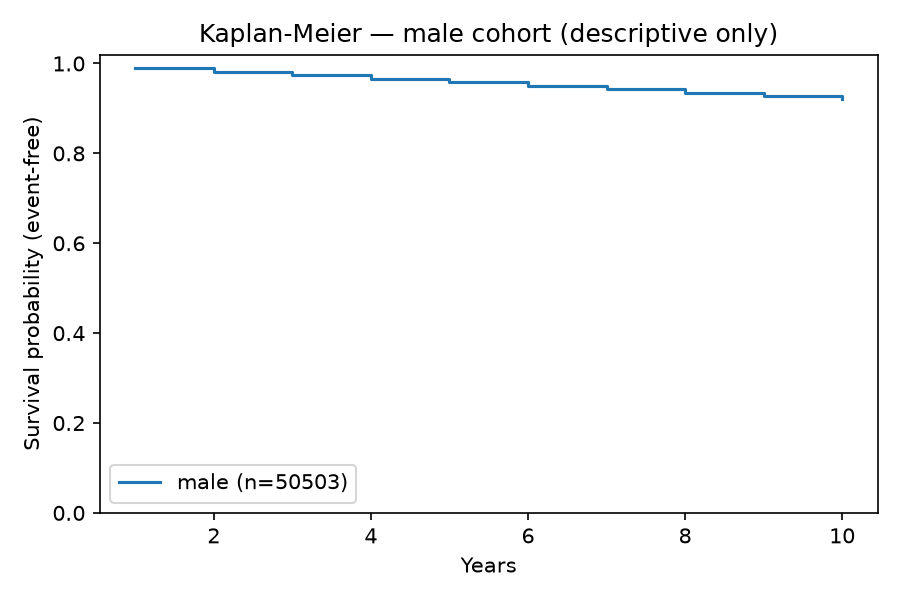


**Kaplan-Meier curve -- female cohort**

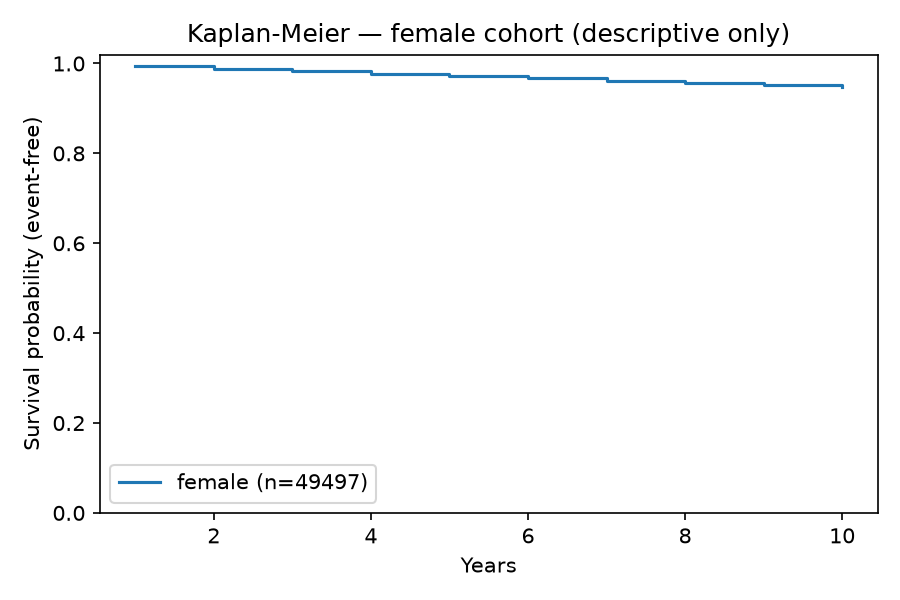


---
## Stage 5 -- Survival ML Models (RSF, GBSA)

Random Survival Forest and Gradient-Boosting Survival Analysis, per sex, on Stage 3's selected feature set (CLAUDE.md §7). Writes `results/tables/stage5_ml_model_predictions_{sex}.csv`; no figures -- formal scoring/plots are deferred to Stage 7.


In [ ]:
"""Stage 5 — survival ML models (CLAUDE.md §7): Random Survival Forest (RSF, Ishwaran et al.,
2008) and Gradient-Boosting Survival Analysis (GBSA, Friedman, 2001), per sex, on Stage 3's
selected feature set (§5.4 — same predictor set as CoxPH, so differences are attributable to
the model, not the inputs). `random_state=42` everywhere a seed is settable (§0.3).

Neither model has an explicitly specified tuning procedure in CLAUDE.md (unlike LASSO's §5.2,
which is explicit about validation-set tuning). Extending that same principle here: a small
grid is fit on the training fold and scored by Harrell's C-index on the validation fold — the
same validation-not-training, validation-not-test discipline used throughout §5/§6 — never an
exhaustive search, to keep runtime reasonable on a single machine; the exact grids are logged
in journal/agent_journal.md.

Formal scoring (C-index, Uno's C, Brier score, calibration, bootstrap 95% CIs — §8/§12) is
deferred to Stage 7 (07_evaluation.py), applied uniformly across all six models, per §11's
architecture (see Stage 4's docstring). Predictions written to
`results/tables/stage5_ml_model_predictions_{sex}.csv`, with both a risk score (C-index) and
a predicted survival probability at the 10-year horizon (Brier score/calibration) per model —
matching the format Stage 4's patch established.
"""

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"
SPLITS = ["train", "val", "test"]
# Integer years 1-10 — matches the dataset's own time resolution. Needed for Stage 7's
# integrated Brier score, which requires survival probabilities across a range, not one point
# (patched in when building Stage 7, same as Stage 4's equivalent patch; see journal).
EVAL_TIME_GRID = list(range(1, 11))
RANDOM_STATE = 42

RSF_GRID = [
    {"n_estimators": n, "max_depth": d}
    for n in (100, 300)
    for d in (None, 8)
]
# Practicality-driven deviation from an exhaustive grid, agreed with the user 2026-08-20: an
# 8-combo grid with n_estimators up to 300 measured at 3+ hours total on this machine, because
# scikit-survival's Cox partial-likelihood loss evaluates the full risk set at every boosting
# stage — cost scales with n_estimators, not meaningfully with max_depth. Capped at
# n_estimators=100 and reduced to 3 combos; subsample=0.5 (stochastic gradient boosting,
# legitimately part of Friedman 2001 — the same paper GBSA is cited to, §7) both speeds up
# each fit and is a real regularisation technique, not just a speed hack.
GBSA_GRID = [
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
]
GBSA_SUBSAMPLE = 0.5


def load_split(sex_label: str, part: str) -> pd.DataFrame:
    path = PROCESSED_DIR / f"{sex_label}_{part}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/02_preprocessing.py first.")
    return pd.read_csv(path)


def load_selected_features(sex_label: str) -> list:
    path = RESULTS_TABLES / f"stage3_feature_selection_{sex_label}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/03_feature_selection.py first.")
    summary = pd.read_csv(path)
    return sorted(summary.loc[summary["final_selected_feature_set"], "predictor"].tolist())


def survival_curve_at_grid(model, X: pd.DataFrame, times=EVAL_TIME_GRID) -> dict:
    """Same rationale as Stage 4's helper of the same name: Stage 7's integrated Brier score
    needs survival probability at multiple time points, not just one."""
    step_functions = model.predict_survival_function(X)
    return {t: np.array([fn(t) for fn in step_functions]) for t in times}


def tune_and_fit(model_cls, grid: list, X_train, y_train, X_val, y_val, sex_label: str,
                  model_name: str, extra_kwargs: dict = None):
    """Fit each grid candidate on the training fold, score by Harrell's C-index on the
    validation fold, return the best-scoring fitted model. Mirrors Stage 3's LASSO alpha
    tuning: validation set decides, training set never leaks into that decision."""
    extra_kwargs = extra_kwargs or {}
    best_model, best_params, best_cindex = None, None, -1.0
    for params in grid:
        model = model_cls(random_state=RANDOM_STATE, **params, **extra_kwargs)
        model.fit(X_train, y_train)
        risk_scores = model.predict(X_val)
        cindex = concordance_index_censored(y_val[EVENT_COL], y_val[TIME_COL], risk_scores)[0]
        print(f"  [{sex_label}] {model_name} {params} -> val C-index = {cindex:.4f}")
        if cindex > best_cindex:
            best_model, best_params, best_cindex = model, params, cindex
    print(f"  [{sex_label}] {model_name} best: {best_params} (val C-index = {best_cindex:.4f})")
    return best_model, best_params, best_cindex


def run_sex_pipeline(sex_label: str) -> None:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    splits = {part: load_split(sex_label, part) for part in SPLITS}
    features = load_selected_features(sex_label)
    print(f"  [{sex_label}] using {len(features)} Stage-3-selected features: {features}")

    X = {part: splits[part][features].astype(float) for part in SPLITS}
    y = {part: Surv.from_dataframe(EVENT_COL, TIME_COL, splits[part]) for part in SPLITS}

    rsf_model, rsf_params, rsf_val_cindex = tune_and_fit(
        RandomSurvivalForest, RSF_GRID, X["train"], y["train"], X["val"], y["val"],
        sex_label, "RSF", extra_kwargs={"n_jobs": -1}
    )
    gbsa_model, gbsa_params, gbsa_val_cindex = tune_and_fit(
        GradientBoostingSurvivalAnalysis, GBSA_GRID, X["train"], y["train"], X["val"], y["val"],
        sex_label, "GBSA", extra_kwargs={"subsample": GBSA_SUBSAMPLE}
    )

    rows = []
    for part in SPLITS:
        df = splits[part]
        rsf_scores = rsf_model.predict(X[part])
        rsf_curve = survival_curve_at_grid(rsf_model, X[part])
        gbsa_scores = gbsa_model.predict(X[part])
        gbsa_curve = survival_curve_at_grid(gbsa_model, X[part])
        row_data = {
            "patient_id": df["patient_id"],
            "split": part,
            TIME_COL: df[TIME_COL],
            EVENT_COL: df[EVENT_COL],
            "rsf_risk_score": rsf_scores,
            "gbsa_risk_score": gbsa_scores,
        }
        for t in EVAL_TIME_GRID:
            row_data[f"rsf_survival_at_{t}y"] = rsf_curve[t]
            row_data[f"gbsa_survival_at_{t}y"] = gbsa_curve[t]
        rows.append(pd.DataFrame(row_data))
    predictions = pd.concat(rows, ignore_index=True)

    for col in ["rsf_risk_score", "gbsa_risk_score"]:
        assert predictions[col].notna().all(), f"[{sex_label}] NaN values in {col}"
    for t in EVAL_TIME_GRID:
        for prefix in ["rsf", "gbsa"]:
            col = f"{prefix}_survival_at_{t}y"
            assert predictions[col].between(0, 1).all(), f"[{sex_label}] {col} outside [0, 1]"

    test_mask = predictions["split"] == "test"
    test_rsf_cindex = concordance_index_censored(
        predictions.loc[test_mask, EVENT_COL].astype(bool),
        predictions.loc[test_mask, TIME_COL],
        predictions.loc[test_mask, "rsf_risk_score"],
    )[0]
    test_gbsa_cindex = concordance_index_censored(
        predictions.loc[test_mask, EVENT_COL].astype(bool),
        predictions.loc[test_mask, TIME_COL],
        predictions.loc[test_mask, "gbsa_risk_score"],
    )[0]
    print(f"  [{sex_label}] test-set C-index (informal check, not the formal §8 evaluation): "
          f"RSF = {test_rsf_cindex:.4f}, GBSA = {test_gbsa_cindex:.4f}")

    out_path = RESULTS_TABLES / f"stage5_ml_model_predictions_{sex_label}.csv"
    predictions.to_csv(out_path, index=False)
    print(f"  [{sex_label}] wrote {out_path}")


def main() -> None:
    RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
    for sex_label in ["male", "female"]:
        try:
            run_sex_pipeline(sex_label)
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)
    print("\n[OK] Stage 5 complete: RSF and GBSA tuned, fitted, and scored for both sexes.")


if __name__ == "__main__":
    main()


---
## Stage 6 -- Deep Survival Models (DeepSurv, DeepHit)

DeepSurv and single-risk DeepHit, per sex, via pycox/torch (CLAUDE.md §7). Writes `results/tables/stage6_deep_survival_predictions_{sex}.csv`; no figures -- same deferred-scoring architecture as Stage 5.


In [ ]:
"""Stage 6 — deep survival models (CLAUDE.md §7): DeepSurv (Katzman et al., 2018) and
DeepHit, single-risk formulation (Lee et al., 2018), per sex, on Stage 3's selected feature
set (§5.4), via `pycox`/`torch`. `random_state=42` applied to both torch and numpy (§0.3).

pycox implements DeepSurv as `pycox.models.CoxPH` — a neural net replacing the linear
predictor in a Cox partial-likelihood model, which is exactly Katzman et al.'s architecture
(a PH-assumption-retaining model, per §7). DeepHit is `pycox.models.DeepHitSingle` — the
single-risk variant is used because this dataset has one composite outcome (§7).

Neural nets need standardised input features (fit on the training fold only, applied to
val/test — no leakage) — `StandardScaler`, used only here since it's a DL-specific
requirement, not part of Stage 2's shared preprocessing.

Per the runtime lesson from Stage 5 (an exhaustive grid made GBSA impractically slow): a
small 2-candidate grid per model, trained with early stopping (which bounds each fit's cost
regardless of the max epoch count), scored by C-index on the validation fold — same
validation-set-decides principle as every other stage, deliberately not exhaustive.

DeepHit's discrete time grid uses `num_durations=10` (one bin per observed year) — a natural,
non-arbitrary choice since `time_to_event_or_censoring` is already integer-valued years 1-10.

Formal scoring (§8) is deferred to Stage 7, same architecture as Stages 4-5. Predictions
written to `results/tables/stage6_deep_survival_predictions_{sex}.csv` with both a risk score
and predicted survival probability at the 10-year horizon per model.
"""

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from pycox.models import CoxPH, DeepHitSingle
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_censored

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"
SPLITS = ["train", "val", "test"]
HORIZON_YEARS = 10.0
# Integer years 1-10 — matches the dataset's own time resolution and DeepHit's own
# num_durations grid. Needed for Stage 7's integrated Brier score, which requires survival
# probabilities across a range, not one point (patched in when building Stage 7; see journal).
EVAL_TIME_GRID = list(range(1, 11))
RANDOM_STATE = 42
NUM_DURATIONS = 10

DEEPSURV_GRID = [
    {"hidden": [32, 32], "lr": 0.01},
    {"hidden": [64, 64], "lr": 0.001},
]
DEEPHIT_GRID = [
    {"hidden": [32, 32], "lr": 0.01},
    {"hidden": [64, 64], "lr": 0.001},
]
BATCH_SIZE = 256
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 10


def set_seed() -> None:
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)


def load_split(sex_label: str, part: str) -> pd.DataFrame:
    path = PROCESSED_DIR / f"{sex_label}_{part}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/02_preprocessing.py first.")
    return pd.read_csv(path)


def load_selected_features(sex_label: str) -> list:
    path = RESULTS_TABLES / f"stage3_feature_selection_{sex_label}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/03_feature_selection.py first.")
    summary = pd.read_csv(path)
    return sorted(summary.loc[summary["final_selected_feature_set"], "predictor"].tolist())


def prepare_arrays(splits: dict, features: list):
    scaler = StandardScaler().fit(splits["train"][features].values)
    X = {
        part: scaler.transform(splits[part][features].values).astype("float32")
        for part in SPLITS
    }
    durations = {
        part: splits[part][TIME_COL].values.astype("float32") for part in SPLITS
    }
    events = {
        part: splits[part][EVENT_COL].values.astype("float32") for part in SPLITS
    }
    return X, durations, events


def build_net(in_features: int, hidden: list, out_features: int):
    return tt.practical.MLPVanilla(
        in_features, hidden, out_features, batch_norm=True, dropout=0.1,
        output_bias=(out_features == 1),
    )


def tune_and_fit_deepsurv(X, durations, events, sex_label: str):
    best_model, best_params, best_cindex = None, None, -1.0
    for params in DEEPSURV_GRID:
        set_seed()
        net = build_net(X["train"].shape[1], params["hidden"], 1)
        model = CoxPH(net, tt.optim.Adam(lr=params["lr"]))
        callbacks = [tt.callbacks.EarlyStopping(patience=EARLY_STOP_PATIENCE)]
        model.fit(
            X["train"], (durations["train"], events["train"]),
            batch_size=BATCH_SIZE, epochs=MAX_EPOCHS, callbacks=callbacks, verbose=False,
            val_data=(X["val"], (durations["val"], events["val"])),
        )
        risk_scores = model.predict(X["val"]).flatten()
        cindex = concordance_index_censored(
            events["val"].astype(bool), durations["val"], risk_scores
        )[0]
        print(f"  [{sex_label}] DeepSurv {params} -> val C-index = {cindex:.4f}")
        if cindex > best_cindex:
            best_model, best_params, best_cindex = model, params, cindex
    print(f"  [{sex_label}] DeepSurv best: {best_params} (val C-index = {best_cindex:.4f})")
    best_model.compute_baseline_hazards()
    return best_model, best_params, best_cindex


def tune_and_fit_deephit(X, durations, events, sex_label: str):
    labtrans = DeepHitSingle.label_transform(NUM_DURATIONS)
    y_train = labtrans.fit_transform(durations["train"], events["train"])
    y_val = labtrans.transform(durations["val"], events["val"])

    best_model, best_params, best_cindex = None, None, -1.0
    for params in DEEPHIT_GRID:
        set_seed()
        net = build_net(X["train"].shape[1], params["hidden"], labtrans.out_features)
        model = DeepHitSingle(
            net, tt.optim.Adam(lr=params["lr"]), duration_index=labtrans.cuts,
            alpha=0.2, sigma=0.1,
        )
        callbacks = [tt.callbacks.EarlyStopping(patience=EARLY_STOP_PATIENCE)]
        model.fit(
            X["train"], y_train, batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
            callbacks=callbacks, verbose=False, val_data=(X["val"], y_val),
        )
        surv_val = model.predict_surv_df(X["val"])
        risk_val = 1.0 - surv_val.loc[surv_val.index <= HORIZON_YEARS].iloc[-1].values
        cindex = concordance_index_censored(
            events["val"].astype(bool), durations["val"], risk_val
        )[0]
        print(f"  [{sex_label}] DeepHit {params} -> val C-index = {cindex:.4f}")
        if cindex > best_cindex:
            best_model, best_params, best_cindex = model, params, cindex
    print(f"  [{sex_label}] DeepHit best: {best_params} (val C-index = {best_cindex:.4f})")
    return best_model, best_params, best_cindex


def survival_at_horizon_from_df(surv_df: pd.DataFrame, horizon: float = HORIZON_YEARS) -> np.ndarray:
    """Both models return a step-function survival DataFrame indexed by time; take the last
    row at or before the horizon (both models' time grids include exactly year 10, since
    training durations are capped there)."""
    at_or_before = surv_df.loc[surv_df.index <= horizon]
    return at_or_before.iloc[-1].values


def survival_curve_at_grid_from_df(surv_df: pd.DataFrame, times=EVAL_TIME_GRID) -> dict:
    """Same rationale as Stages 4-5's `survival_curve_at_grid`: Stage 7's integrated Brier
    score needs survival probability at multiple time points, not just one."""
    return {t: survival_at_horizon_from_df(surv_df, horizon=t) for t in times}


def run_sex_pipeline(sex_label: str) -> None:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    splits = {part: load_split(sex_label, part) for part in SPLITS}
    features = load_selected_features(sex_label)
    print(f"  [{sex_label}] using {len(features)} Stage-3-selected features: {features}")

    X, durations, events = prepare_arrays(splits, features)

    deepsurv_model, deepsurv_params, _ = tune_and_fit_deepsurv(X, durations, events, sex_label)
    deephit_model, deephit_params, _ = tune_and_fit_deephit(X, durations, events, sex_label)

    rows = []
    for part in SPLITS:
        df = splits[part]
        deepsurv_scores = deepsurv_model.predict(X[part]).flatten()
        deepsurv_surv_df = deepsurv_model.predict_surv_df(X[part])
        deepsurv_curve = survival_curve_at_grid_from_df(deepsurv_surv_df)

        deephit_surv_df = deephit_model.predict_surv_df(X[part])
        deephit_curve = survival_curve_at_grid_from_df(deephit_surv_df)
        deephit_scores = 1.0 - deephit_curve[HORIZON_YEARS]

        row_data = {
            "patient_id": df["patient_id"],
            "split": part,
            TIME_COL: df[TIME_COL],
            EVENT_COL: df[EVENT_COL],
            "deepsurv_risk_score": deepsurv_scores,
            "deephit_risk_score": deephit_scores,
        }
        for t in EVAL_TIME_GRID:
            row_data[f"deepsurv_survival_at_{t}y"] = deepsurv_curve[t]
            row_data[f"deephit_survival_at_{t}y"] = deephit_curve[t]
        rows.append(pd.DataFrame(row_data))
    predictions = pd.concat(rows, ignore_index=True)

    for col in ["deepsurv_risk_score", "deephit_risk_score"]:
        assert predictions[col].notna().all(), f"[{sex_label}] NaN values in {col}"
    for t in EVAL_TIME_GRID:
        for prefix in ["deepsurv", "deephit"]:
            col = f"{prefix}_survival_at_{t}y"
            assert predictions[col].between(0, 1).all(), f"[{sex_label}] {col} outside [0, 1]"

    test_mask = predictions["split"] == "test"
    test_deepsurv_cindex = concordance_index_censored(
        predictions.loc[test_mask, EVENT_COL].astype(bool),
        predictions.loc[test_mask, TIME_COL],
        predictions.loc[test_mask, "deepsurv_risk_score"],
    )[0]
    test_deephit_cindex = concordance_index_censored(
        predictions.loc[test_mask, EVENT_COL].astype(bool),
        predictions.loc[test_mask, TIME_COL],
        predictions.loc[test_mask, "deephit_risk_score"],
    )[0]
    print(f"  [{sex_label}] test-set C-index (informal check, not the formal §8 evaluation): "
          f"DeepSurv = {test_deepsurv_cindex:.4f}, DeepHit = {test_deephit_cindex:.4f}")

    out_path = RESULTS_TABLES / f"stage6_deep_survival_predictions_{sex_label}.csv"
    predictions.to_csv(out_path, index=False)
    print(f"  [{sex_label}] wrote {out_path}")


def main() -> None:
    RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
    for sex_label in ["male", "female"]:
        try:
            run_sex_pipeline(sex_label)
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)
    print("\n[OK] Stage 6 complete: DeepSurv and DeepHit tuned, fitted, and scored for "
          "both sexes.")


if __name__ == "__main__":
    main()


---
## Stage 7 -- Evaluation

C-index, Uno's IPCW C-statistic, integrated Brier score, and calibration plots with bootstrap 95% CIs, applied uniformly to all six models per sex on the held-out test set (CLAUDE.md §8/§12). Writes `results/tables/stage7_evaluation_summary.csv` and the calibration figures.


In [ ]:
"""Stage 7 — evaluation (CLAUDE.md §8/§12): C-index (Harrell et al., 1982), Uno's IPCW
C-statistic (Uno et al., 2011), integrated Brier score (Graf et al., 1999) with calibration
plots, all with bootstrap 95% CIs — applied uniformly to all six models, per sex, on the test
set only (§6: held out exclusively for final evaluation).

Every reported number is compared against the sex-specific CoxPH *and* QRISK3-style baselines
with an effect size (paired bootstrap difference) and CI, per §8's last bullet.

**IPCW time-grid technical constraint, discovered while building this stage:**
`sksurv`'s IPCW-weighted estimators (Uno's C, Brier score) require evaluation times strictly
less than the test set's maximum follow-up time — the censoring-distribution estimator is
undefined exactly at that boundary, since ~93% of patients are administratively censored at
exactly year 10 (Stage 1's censoring profile). Evaluated up to 9.99 years instead of exactly
10 (`TAU`) — a standard, well-understood technical workaround in this literature, not a scope
reduction: every model is still assessed at essentially the 10-year horizon the spec asks
for.

**QRISK3-style score gets a single-timepoint Brier score, not the integrated version** — it
has no multi-year curve (§7: fixed clinical formula, not a fitted survival model; see the
Stages 4-6 patch note in the journal, 2026-08-20). Labelled explicitly as such in the output
table, not silently presented as equivalent to the other five models' integrated score.
"""

import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sksurv.metrics import brier_score, concordance_index_censored, concordance_index_ipcw, \
    integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"
TAU = 9.99  # see module docstring — just inside the [min, max) domain sksurv requires
IBS_TIMES = [1, 2, 3, 4, 5, 6, 7, 8, 9, TAU]
N_BOOTSTRAP = 1000
RANDOM_STATE = 42
N_DECILES = 10

# model -> (risk score column, dict of {t: survival column} or None if no curve, source table)
MODELS = {
    "coxph": {"risk_col": "coxph_risk_score", "has_curve": True, "table": "stage4"},
    "qrisk3_style": {"risk_col": "qrisk3_style_score", "has_curve": False, "table": "stage4"},
    "rsf": {"risk_col": "rsf_risk_score", "has_curve": True, "table": "stage5"},
    "gbsa": {"risk_col": "gbsa_risk_score", "has_curve": True, "table": "stage5"},
    "deepsurv": {"risk_col": "deepsurv_risk_score", "has_curve": True, "table": "stage6"},
    "deephit": {"risk_col": "deephit_risk_score", "has_curve": True, "table": "stage6"},
}
BASELINE_MODELS = ["coxph", "qrisk3_style"]


def load_test_predictions(sex_label: str) -> pd.DataFrame:
    tables = {}
    for name in ["stage4_baseline", "stage5_ml_model", "stage6_deep_survival"]:
        path = RESULTS_TABLES / f"{name}_predictions_{sex_label}.csv"
        if not path.exists():
            raise FileNotFoundError(f"{path} not found — run the corresponding stage first.")
        df = pd.read_csv(path)
        tables[name.split("_")[0]] = df[df["split"] == "test"].reset_index(drop=True)

    merged = tables["stage4"]
    for key in ["stage5", "stage6"]:
        merged = merged.merge(
            tables[key].drop(columns=[TIME_COL, EVENT_COL, "split"]),
            on="patient_id", how="inner", validate="one_to_one",
        )
    assert len(merged) == len(tables["stage4"]), "test-set row count changed after merge"
    return merged


def curve_matrix(df: pd.DataFrame, model_name: str) -> np.ndarray:
    """Each model's survival probability at every point in IBS_TIMES (9.99 uses the year-10
    column — the last observed step in a right-continuous step function doesn't change
    between t=9.99 and t=10, so this is exact, not an approximation)."""
    cols = [f"{model_name}_survival_at_{t}y" for t in [1, 2, 3, 4, 5, 6, 7, 8, 9]] + \
           [f"{model_name}_survival_at_10y"]
    return df[cols].values


def qrisk3_survival_10y(df: pd.DataFrame) -> np.ndarray:
    return 1.0 - df["qrisk3_style_score"].values / 100.0


def compute_metrics(model_name: str, df: pd.DataFrame, y_train, idx: np.ndarray) -> dict:
    """§8: C-index, Uno's C, and Brier score (integrated for curve models, single-timepoint
    at TAU for QRISK3-style) for one bootstrap resample (or the full set if idx covers it)."""
    spec = MODELS[model_name]
    sub = df.iloc[idx]
    y_sub = Surv.from_dataframe(EVENT_COL, TIME_COL, sub)
    risk = sub[spec["risk_col"]].values

    cindex = concordance_index_censored(y_sub[EVENT_COL], y_sub[TIME_COL], risk)[0]
    uno = concordance_index_ipcw(y_train, y_sub, risk, tau=TAU)[0]

    if spec["has_curve"]:
        curve = curve_matrix(sub, model_name)
        brier = integrated_brier_score(y_train, y_sub, curve, IBS_TIMES)
    else:
        surv_10y = qrisk3_survival_10y(sub).reshape(-1, 1)
        brier = brier_score(y_train, y_sub, surv_10y, [TAU])[1][0]

    return {"cindex": cindex, "uno_cindex": uno, "brier": brier}


def bootstrap_all_models(df: pd.DataFrame, y_train, sex_label: str) -> pd.DataFrame:
    n = len(df)
    rng = np.random.default_rng(RANDOM_STATE)
    full_idx = np.arange(n)

    point = {m: compute_metrics(m, df, y_train, full_idx) for m in MODELS}
    print(f"  [{sex_label}] point estimates:")
    for m, vals in point.items():
        print(f"    {m}: C-index={vals['cindex']:.4f}, Uno's C={vals['uno_cindex']:.4f}, "
              f"Brier={vals['brier']:.4f}")

    boot = {m: {"cindex": [], "uno_cindex": [], "brier": []} for m in MODELS}
    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)
        for m in MODELS:
            result = compute_metrics(m, df, y_train, idx)
            for k, v in result.items():
                boot[m][k].append(v)
        if (b + 1) % 250 == 0:
            print(f"  [{sex_label}] bootstrap {b + 1}/{N_BOOTSTRAP}")

    rows = []
    for m in MODELS:
        row = {"sex": sex_label, "model": m,
               "brier_score_type": "integrated" if MODELS[m]["has_curve"]
                                    else "single_timepoint_9.99y"}
        for metric in ["cindex", "uno_cindex", "brier"]:
            vals = np.array(boot[m][metric])
            row[metric] = point[m][metric]
            row[f"{metric}_ci_low"] = np.percentile(vals, 2.5)
            row[f"{metric}_ci_high"] = np.percentile(vals, 97.5)
        for baseline in BASELINE_MODELS:
            if m == baseline:
                continue
            for metric in ["cindex", "uno_cindex", "brier"]:
                diffs = np.array(boot[m][metric]) - np.array(boot[baseline][metric])
                row[f"delta_{metric}_vs_{baseline}"] = point[m][metric] - point[baseline][metric]
                row[f"delta_{metric}_vs_{baseline}_ci_low"] = np.percentile(diffs, 2.5)
                row[f"delta_{metric}_vs_{baseline}_ci_high"] = np.percentile(diffs, 97.5)
        rows.append(row)
    return pd.DataFrame(rows)


def decile_calibration(df: pd.DataFrame, model_name: str):
    """§8: observed vs predicted 10-year event probability, decile-grouped. Observed
    probability uses a KM estimate within each decile (accounts for censoring properly),
    not a naive raw event proportion."""
    spec = MODELS[model_name]
    predicted_risk = (1.0 - qrisk3_survival_10y(df)) if not spec["has_curve"] \
        else (1.0 - df[f"{model_name}_survival_at_10y"].values)

    deciles = pd.qcut(predicted_risk, N_DECILES, labels=False, duplicates="drop")
    mean_predicted, observed = [], []
    for d in sorted(pd.unique(deciles)):
        mask = deciles == d
        mean_predicted.append(predicted_risk[mask].mean())
        time_d, surv_d = kaplan_meier_estimator(
            df.loc[mask, EVENT_COL].astype(bool), df.loc[mask, TIME_COL]
        )
        at_or_before = surv_d[time_d <= TAU]
        surv_at_tau = at_or_before[-1] if len(at_or_before) else 1.0
        observed.append(1.0 - surv_at_tau)
    return np.array(mean_predicted), np.array(observed)


def plot_calibration_grid(df: pd.DataFrame, sex_label: str) -> None:
    curves = {m: decile_calibration(df, m) for m in MODELS}
    shared_lim = max(max(pred.max(), obs.max()) for pred, obs in curves.values()) * 1.1

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, model_name in zip(axes.flat, MODELS):
        pred, obs = curves[model_name]
        ax.plot([0, shared_lim], [0, shared_lim], linestyle="--", color="gray", linewidth=1)
        ax.plot(pred, obs, marker="o")
        ax.set_title(model_name)
        ax.set_xlabel("Mean predicted 10y risk")
        ax.set_ylabel("Observed 10y risk (KM)")
        ax.set_xlim(0, shared_lim)
        ax.set_ylim(0, shared_lim)
    fig.suptitle(f"Calibration — {sex_label} cohort, decile-grouped")
    fig.tight_layout()
    out_path = RESULTS_FIGURES / f"calibration_{sex_label}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"  [{sex_label}] calibration grid saved to {out_path}")


def run_sex_pipeline(sex_label: str) -> pd.DataFrame:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    train_df = pd.read_csv(PROCESSED_DIR / f"{sex_label}_train.csv")
    y_train = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    test_df = load_test_predictions(sex_label)
    print(f"  [{sex_label}] test set: {len(test_df)} patients")

    summary = bootstrap_all_models(test_df, y_train, sex_label)
    plot_calibration_grid(test_df, sex_label)
    return summary


def main() -> None:
    RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
    RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
    all_summaries = []
    for sex_label in ["male", "female"]:
        try:
            all_summaries.append(run_sex_pipeline(sex_label))
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)

    final = pd.concat(all_summaries, ignore_index=True)
    for metric in ["cindex", "uno_cindex", "brier"]:
        assert final[metric].between(-0.01, 1.01).all(), f"{metric} outside plausible [0,1] range"
        assert (final[f"{metric}_ci_low"] <= final[metric] + 1e-9).all(), (
            f"{metric} point estimate falls below its own CI lower bound"
        )
        assert (final[f"{metric}_ci_high"] >= final[metric] - 1e-9).all(), (
            f"{metric} point estimate falls above its own CI upper bound"
        )

    out_path = RESULTS_TABLES / "stage7_evaluation_summary.csv"
    final.to_csv(out_path, index=False)
    print(f"\n[OK] Stage 7 complete: six-model x two-sex evaluation table written to {out_path}")


if __name__ == "__main__":
    main()


**Calibration plot -- male cohort**

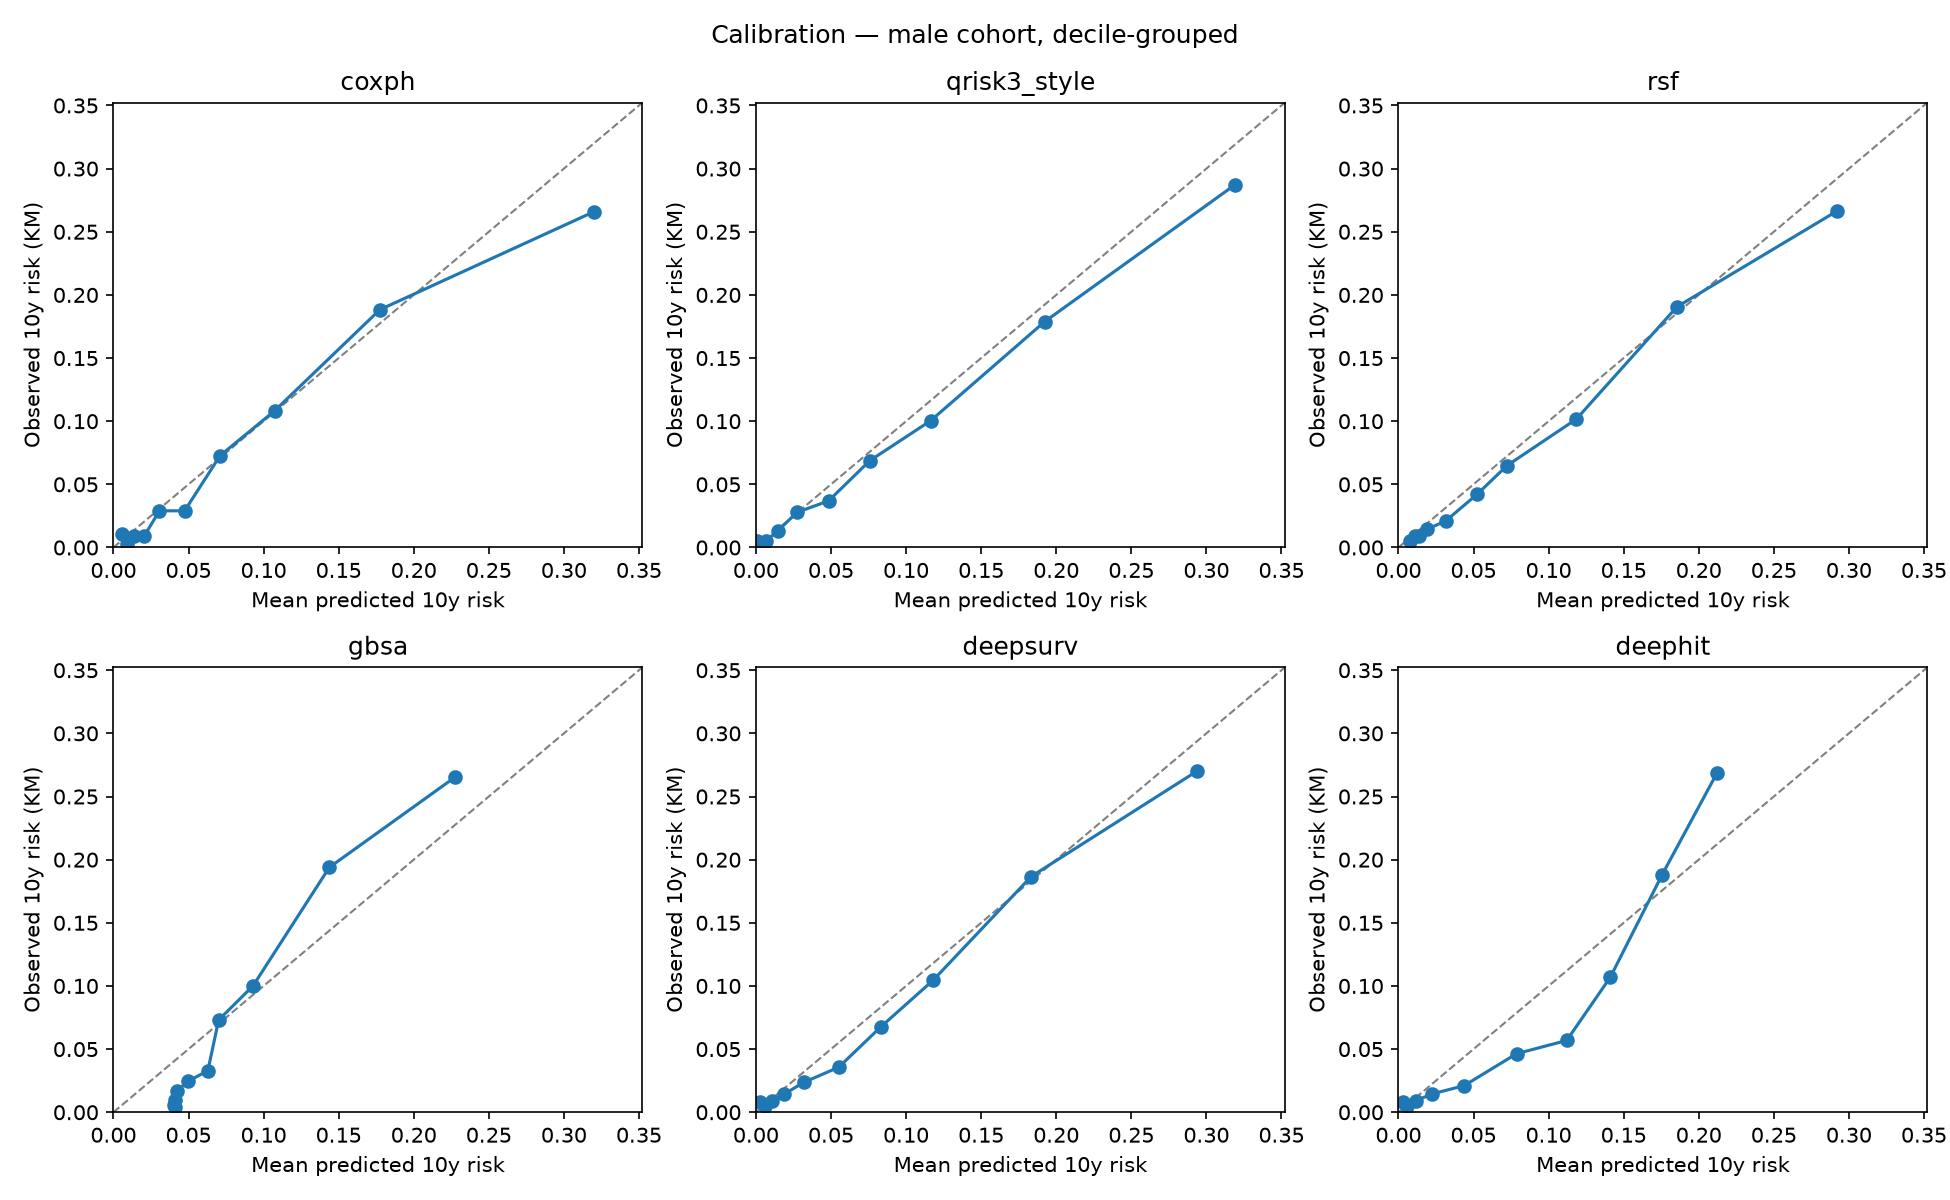


**Calibration plot -- female cohort**

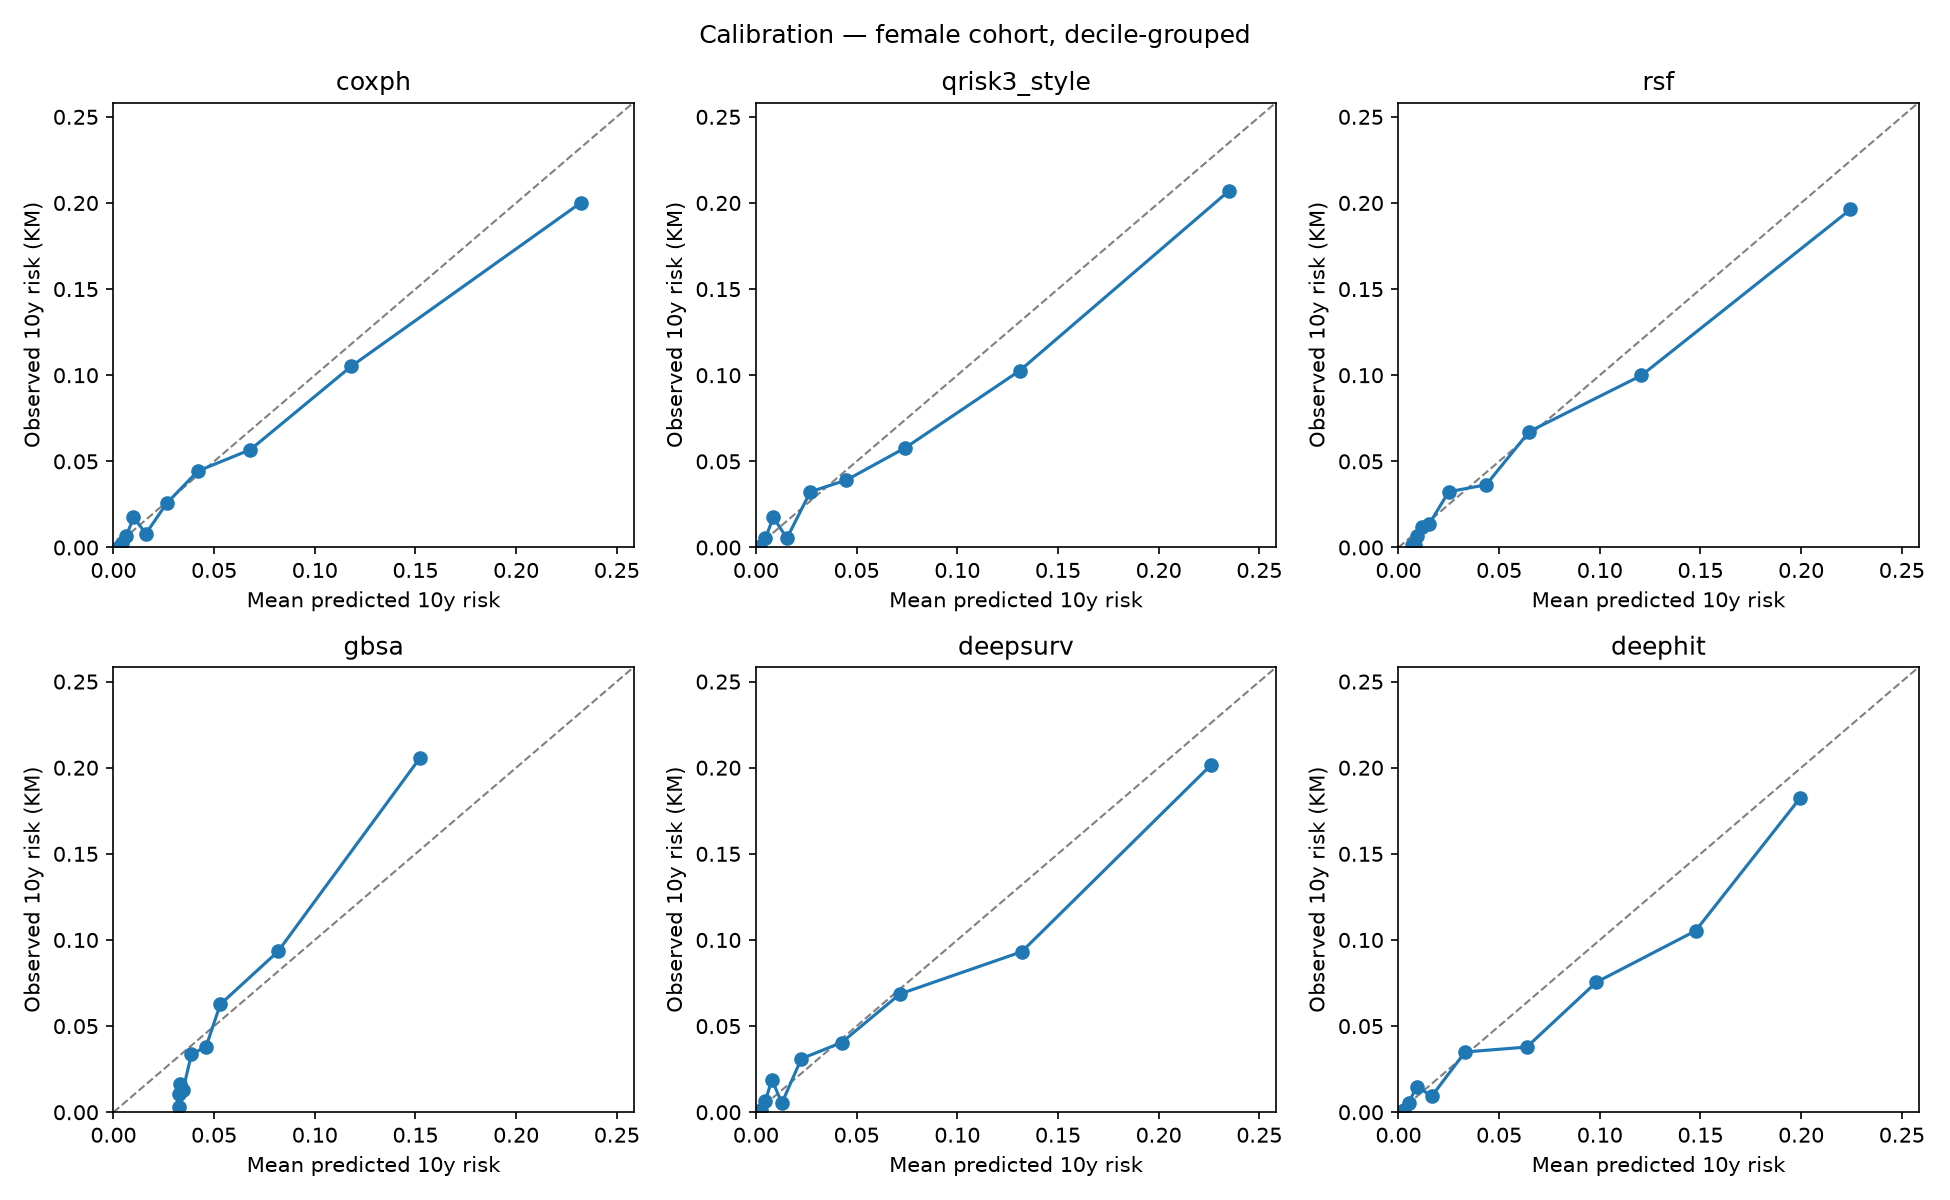


**Six-model x two-sex evaluation summary**

| sex | model | brier_score_type | cindex | cindex_ci_low | cindex_ci_high | uno_cindex | uno_cindex_ci_low | uno_cindex_ci_high | brier | brier_ci_low | brier_ci_high | delta_cindex_vs_qrisk3_style | delta_cindex_vs_qrisk3_style_ci_low | delta_cindex_vs_qrisk3_style_ci_high | delta_uno_cindex_vs_qrisk3_style | delta_uno_cindex_vs_qrisk3_style_ci_low | delta_uno_cindex_vs_qrisk3_style_ci_high | delta_brier_vs_qrisk3_style | delta_brier_vs_qrisk3_style_ci_low | delta_brier_vs_qrisk3_style_ci_high | delta_cindex_vs_coxph | delta_cindex_vs_coxph_ci_low | delta_cindex_vs_coxph_ci_high | delta_uno_cindex_vs_coxph | delta_uno_cindex_vs_coxph_ci_low | delta_uno_cindex_vs_coxph_ci_high | delta_brier_vs_coxph | delta_brier_vs_coxph_ci_low | delta_brier_vs_coxph_ci_high |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| male | coxph | integrated | 0.8098 | 0.7945 | 0.8240 | 0.8134 | 0.7963 | 0.8284 | 0.0390 | 0.0360 | 0.0422 | -0.0098 | -0.0168 | -0.0030 | -0.0104 | -0.0183 | -0.0032 | -0.0197 | -0.0217 | -0.0178 | nan | nan | nan | nan | nan | nan | nan | nan | nan |
| male | qrisk3_style | single_timepoint_9.99y | 0.8196 | 0.8058 | 0.8337 | 0.8238 | 0.8096 | 0.8389 | 0.0588 | 0.0548 | 0.0628 | nan | nan | nan | nan | nan | nan | nan | nan | nan | 0.0098 | 0.0030 | 0.0168 | 0.0104 | 0.0032 | 0.0183 | 0.0197 | 0.0178 | 0.0217 |
| male | rsf | integrated | 0.8073 | 0.7924 | 0.8222 | 0.8110 | 0.7944 | 0.8262 | 0.0392 | 0.0362 | 0.0424 | -0.0124 | -0.0185 | -0.0065 | -0.0129 | -0.0193 | -0.0067 | -0.0196 | -0.0216 | -0.0176 | -0.0026 | -0.0065 | 0.0012 | -0.0024 | -0.0064 | 0.0012 | 0.0002 | -0.0001 | 0.0004 |
| male | gbsa | integrated | 0.8086 | 0.7938 | 0.8229 | 0.8131 | 0.7968 | 0.8281 | 0.0398 | 0.0366 | 0.0432 | -0.0110 | -0.0179 | -0.0048 | -0.0108 | -0.0181 | -0.0041 | -0.0190 | -0.0211 | -0.0170 | -0.0012 | -0.0043 | 0.0023 | -0.0004 | -0.0036 | 0.0030 | 0.0007 | 0.0003 | 0.0011 |
| male | deepsurv | integrated | 0.8089 | 0.7935 | 0.8237 | 0.8119 | 0.7953 | 0.8271 | 0.0392 | 0.0362 | 0.0424 | -0.0107 | -0.0176 | -0.0045 | -0.0119 | -0.0195 | -0.0053 | -0.0196 | -0.0216 | -0.0176 | -0.0009 | -0.0037 | 0.0017 | -0.0015 | -0.0044 | 0.0012 | 0.0002 | -0.0001 | 0.0004 |
| male | deephit | integrated | 0.8085 | 0.7935 | 0.8233 | 0.8120 | 0.7953 | 0.8274 | 0.0399 | 0.0367 | 0.0432 | -0.0112 | -0.0185 | -0.0040 | -0.0118 | -0.0200 | -0.0045 | -0.0188 | -0.0210 | -0.0168 | -0.0014 | -0.0046 | 0.0021 | -0.0014 | -0.0048 | 0.0022 | 0.0009 | 0.0004 | 0.0014 |
| female | coxph | integrated | 0.8192 | 0.8014 | 0.8380 | 0.8207 | 0.8007 | 0.8393 | 0.0265 | 0.0238 | 0.0291 | -0.0043 | -0.0122 | 0.0008 | -0.0051 | -0.0139 | 0.0005 | -0.0143 | -0.0159 | -0.0125 | nan | nan | nan | nan | nan | nan | nan | nan | nan |
| female | qrisk3_style | single_timepoint_9.99y | 0.8235 | 0.8061 | 0.8413 | 0.8258 | 0.8072 | 0.8434 | 0.0407 | 0.0375 | 0.0441 | nan | nan | nan | nan | nan | nan | nan | nan | nan | 0.0043 | -0.0008 | 0.0122 | 0.0051 | -0.0005 | 0.0139 | 0.0143 | 0.0125 | 0.0159 |
| female | rsf | integrated | 0.8127 | 0.7943 | 0.8311 | 0.8146 | 0.7950 | 0.8333 | 0.0266 | 0.0239 | 0.0292 | -0.0108 | -0.0174 | -0.0052 | -0.0112 | -0.0187 | -0.0054 | -0.0142 | -0.0159 | -0.0124 | -0.0065 | -0.0111 | -0.0012 | -0.0061 | -0.0114 | -0.0004 | 0.0001 | -0.0001 | 0.0002 |
| female | gbsa | integrated | 0.8141 | 0.7951 | 0.8333 | 0.8167 | 0.7960 | 0.8360 | 0.0267 | 0.0240 | 0.0294 | -0.0094 | -0.0184 | -0.0026 | -0.0091 | -0.0186 | -0.0016 | -0.0140 | -0.0157 | -0.0122 | -0.0051 | -0.0091 | -0.0014 | -0.0040 | -0.0082 | -0.0002 | 0.0003 | -0.0000 | 0.0006 |
| female | deepsurv | integrated | 0.8151 | 0.7973 | 0.8332 | 0.8167 | 0.7970 | 0.8347 | 0.0266 | 0.0239 | 0.0293 | -0.0084 | -0.0151 | -0.0033 | -0.0091 | -0.0164 | -0.0033 | -0.0142 | -0.0158 | -0.0124 | -0.0041 | -0.0077 | 0.0002 | -0.0040 | -0.0081 | 0.0006 | 0.0001 | -0.0001 | 0.0003 |
| female | deephit | integrated | 0.8113 | 0.7941 | 0.8288 | 0.8130 | 0.7944 | 0.8307 | 0.0267 | 0.0241 | 0.0294 | -0.0122 | -0.0186 | -0.0070 | -0.0128 | -0.0200 | -0.0070 | -0.0140 | -0.0157 | -0.0123 | -0.0079 | -0.0131 | -0.0024 | -0.0077 | -0.0133 | -0.0019 | 0.0002 | -0.0000 | 0.0005 |



---
## Stage 8 -- Explainability (SHAP, LIME, stability)

SHAP and LIME on all four ML/DL models, per sex, with stability testing across resampled training folds before any ranking is treated as robust (CLAUDE.md §9). Writes the SHAP figures plus the stability and SHAP/LIME agreement tables.


In [ ]:
"""Stage 8 — explainability (CLAUDE.md §9): SHAP (Lundberg and Lee, 2017) and LIME (Ribeiro,
Singh and Guestrin, 2016) on all four ML/DL models (RSF, GBSA, DeepSurv, DeepHit), per sex,
with stability testing across resampled training folds (§9.4) before any ranking is treated
as a robust claim.

Each of the four models is refit here using the exact best hyperparameters already found and
recorded in Stages 5-6 (no re-tuning — SHAP/LIME need a live model object with a callable
predict function, which Stages 5-6 didn't persist, only predictions). `random_state=42` for
the main fit; 2 further bootstrap resamples of the training fold (seeds 43, 44) for §9.4's
stability test, refit with the *same* fixed hyperparameters.

**SHAP explainer choice, verified empirically before committing (§14):** `shap.TreeExplainer`
does not support `sksurv` models (`InvalidModelError`, confirmed directly). Used
`shap.Explainer` with each model's `.predict()` as a black-box function instead — works
uniformly across all four heterogeneous model types (tree-based and neural). With only 9-10
features, SHAP automatically selects its exact-computation explainer (not the slow Kernel
approximation), confirmed via timing test: ~0.09-0.15s/sample regardless of model type.
GBSA's ~6-minute fit time (already characterised in Stage 5) is the only real cost here — SHAP
explanation itself is fast for every model.

**BMI dependence plot, resolved before coding (§14):** §9 asks for dependence plots on "age,
systolic BP, BMI," but BMI was dropped by Stage 3's LASSO for *both* sexes — it is not an
input to any of the four models. Only age and systolic BP remain as continuous predictors;
dependence plots cover those two, per the user's decision. This is a direct, already-logged
consequence of Stage 3's own feature selection, not a new deviation.
"""

import sys
import warnings
from pathlib import Path

import lime.lime_tabular
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torchtuples as tt
from pycox.models import CoxPH as DeepSurv
from pycox.models import DeepHitSingle
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv

warnings.filterwarnings("ignore", message="X does not have valid feature names")

PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

EVENT_COL = "heart_attack_or_stroke_occurred"
TIME_COL = "time_to_event_or_censoring"
RANDOM_STATE = 42
STABILITY_SEEDS = [43, 44]
N_EXPLAIN_SAMPLE = 200
N_BACKGROUND = 50
TOP_K_AGREEMENT = 3
CONTINUOUS_FOR_DEPENDENCE = ["age", "systolic_blood_pressure"]
NUM_DURATIONS = 10

MODEL_HYPERPARAMS = {
    "male": {
        "rsf": {"n_estimators": 300, "max_depth": 8},
        "gbsa": {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "subsample": 0.5},
        "deepsurv": {"hidden": [64, 64], "lr": 0.001},
        "deephit": {"hidden": [64, 64], "lr": 0.001},
    },
    "female": {
        "rsf": {"n_estimators": 300, "max_depth": 8},
        "gbsa": {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "subsample": 0.5},
        "deepsurv": {"hidden": [32, 32], "lr": 0.01},
        "deephit": {"hidden": [32, 32], "lr": 0.01},
    },
}


def load_split(sex_label: str, part: str) -> pd.DataFrame:
    path = PROCESSED_DIR / f"{sex_label}_{part}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/02_preprocessing.py first.")
    return pd.read_csv(path)


def load_selected_features(sex_label: str) -> list:
    path = RESULTS_TABLES / f"stage3_feature_selection_{sex_label}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run src/03_feature_selection.py first.")
    summary = pd.read_csv(path)
    return sorted(summary.loc[summary["final_selected_feature_set"], "predictor"].tolist())


def bootstrap_resample(df: pd.DataFrame, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(df), len(df))
    return df.iloc[idx].reset_index(drop=True)


# --- Model fitting (fixed hyperparameters from Stages 5-6, no re-tuning) --------------------

def fit_rsf(train_df: pd.DataFrame, features: list, params: dict, seed: int):
    X = train_df[features].astype(float)
    y = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    model = RandomSurvivalForest(random_state=seed, n_jobs=-1, **params)
    model.fit(X, y)
    return lambda arr: model.predict(pd.DataFrame(arr, columns=features))


def fit_gbsa(train_df: pd.DataFrame, features: list, params: dict, seed: int):
    X = train_df[features].astype(float)
    y = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    model = GradientBoostingSurvivalAnalysis(random_state=seed, **params)
    model.fit(X, y)
    return lambda arr: model.predict(pd.DataFrame(arr, columns=features))


def fit_deepsurv(train_df: pd.DataFrame, features: list, params: dict, seed: int):
    scaler = StandardScaler().fit(train_df[features].values)
    X = scaler.transform(train_df[features].values).astype("float32")
    durations = train_df[TIME_COL].values.astype("float32")
    events = train_df[EVENT_COL].values.astype("float32")

    torch.manual_seed(seed)
    net = tt.practical.MLPVanilla(len(features), params["hidden"], 1, batch_norm=True,
                                   dropout=0.1, output_bias=True)
    model = DeepSurv(net, tt.optim.Adam(lr=params["lr"]))
    model.fit(X, (durations, events), batch_size=256, epochs=100, verbose=False,
              callbacks=[tt.callbacks.EarlyStopping(patience=10)])
    return lambda arr: model.predict(scaler.transform(np.asarray(arr)).astype("float32")).flatten()


def fit_deephit(train_df: pd.DataFrame, features: list, params: dict, seed: int):
    scaler = StandardScaler().fit(train_df[features].values)
    X = scaler.transform(train_df[features].values).astype("float32")
    durations = train_df[TIME_COL].values.astype("float32")
    events = train_df[EVENT_COL].values.astype("float32")

    labtrans = DeepHitSingle.label_transform(NUM_DURATIONS)
    y = labtrans.fit_transform(durations, events)

    torch.manual_seed(seed)
    net = tt.practical.MLPVanilla(len(features), params["hidden"], labtrans.out_features,
                                   batch_norm=True, dropout=0.1)
    model = DeepHitSingle(net, tt.optim.Adam(lr=params["lr"]), duration_index=labtrans.cuts,
                           alpha=0.2, sigma=0.1)
    model.fit(X, y, batch_size=256, epochs=100, verbose=False,
              callbacks=[tt.callbacks.EarlyStopping(patience=10)])

    def predict_fn(arr):
        surv_df = model.predict_surv_df(scaler.transform(np.asarray(arr)).astype("float32"))
        at_or_before = surv_df.loc[surv_df.index <= 10]
        return 1.0 - at_or_before.iloc[-1].values

    return predict_fn


FITTERS = {"rsf": fit_rsf, "gbsa": fit_gbsa, "deepsurv": fit_deepsurv, "deephit": fit_deephit}
MODEL_NAMES = ["rsf", "gbsa", "deepsurv", "deephit"]


def fit_coxph_coefficients(train_df: pd.DataFrame, features: list) -> pd.Series:
    X = train_df[features].astype(float)
    y = Surv.from_dataframe(EVENT_COL, TIME_COL, train_df)
    model = CoxPHSurvivalAnalysis()
    model.fit(X, y)
    return pd.Series(model.coef_, index=features)


# --- SHAP / LIME -------------------------------------------------------------------------

def compute_shap_mean_abs(predict_fn, X_train: pd.DataFrame, X_explain: pd.DataFrame,
                           features: list) -> pd.Series:
    background = shap.sample(X_train[features], N_BACKGROUND, random_state=RANDOM_STATE)
    explainer = shap.Explainer(predict_fn, background)
    sv = explainer(X_explain[features])
    return pd.Series(np.abs(sv.values).mean(axis=0), index=features)


def top_k_features(values: pd.Series, k: int = TOP_K_AGREEMENT) -> set:
    return set(values.abs().sort_values(ascending=False).index[:k])


def compute_lime_top_features(predict_fn, X_train: pd.DataFrame, X_explain: pd.DataFrame,
                               features: list) -> list:
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train[features].values, feature_names=features, mode="regression",
        random_state=RANDOM_STATE,
    )
    results = []
    for _, row in X_explain[features].iterrows():
        exp = explainer.explain_instance(row.values, predict_fn, num_features=len(features))
        weights = pd.Series({features[i]: w for i, w in exp.as_map()[1]})
        results.append(top_k_features(weights))
    return results


# --- Plots ---------------------------------------------------------------------------------

def plot_shap_summary(sex_label: str, shap_by_model: dict, coxph_coef: pd.Series,
                       features: list) -> None:
    fig, ax = plt.subplots(figsize=(9, 6))
    y_pos = np.arange(len(features))
    width = 0.15
    series = {**{m: shap_by_model[m] / shap_by_model[m].max() for m in MODEL_NAMES},
              "coxph (|coef|)": coxph_coef.abs() / coxph_coef.abs().max()}
    for i, (name, vals) in enumerate(series.items()):
        ax.barh(y_pos + i * width, vals[features].values, height=width, label=name)
    ax.set_yticks(y_pos + width * (len(series) - 1) / 2)
    ax.set_yticklabels(features)
    ax.set_xlabel("Normalised importance (mean |SHAP| or |coefficient|, scaled to own max)")
    ax.set_title(f"Feature importance — {sex_label} cohort")
    ax.legend(loc="lower right", fontsize=8)
    ax.invert_yaxis()
    fig.tight_layout()
    out_path = RESULTS_FIGURES / f"shap_summary_{sex_label}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"  [{sex_label}] SHAP summary saved to {out_path}")


def plot_shap_dependence(sex_label: str, shap_values_by_model: dict,
                          X_explain: pd.DataFrame) -> None:
    fig, axes = plt.subplots(len(MODEL_NAMES), len(CONTINUOUS_FOR_DEPENDENCE),
                              figsize=(4 * len(CONTINUOUS_FOR_DEPENDENCE), 3.2 * len(MODEL_NAMES)))
    for row, model_name in enumerate(MODEL_NAMES):
        sv = shap_values_by_model[model_name]
        for col, feat in enumerate(CONTINUOUS_FOR_DEPENDENCE):
            ax = axes[row, col]
            ax.scatter(X_explain[feat].values, sv[:, X_explain.columns.get_loc(feat)],
                       s=10, alpha=0.6)
            ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            ax.set_xlabel(feat)
            ax.set_ylabel(f"{model_name}\nSHAP value" if col == 0 else "SHAP value")
    fig.suptitle(f"SHAP dependence — {sex_label} cohort (age, systolic BP — see docstring "
                 f"re: BMI)")
    fig.tight_layout()
    out_path = RESULTS_FIGURES / f"shap_dependence_{sex_label}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"  [{sex_label}] SHAP dependence grid saved to {out_path}")


# --- Orchestration -----------------------------------------------------------------------

def run_sex_pipeline(sex_label: str) -> None:
    print(f"\n--- {sex_label.capitalize()} cohort ---")
    train_df = load_split(sex_label, "train")
    test_df = load_split(sex_label, "test")
    features = load_selected_features(sex_label)
    params = MODEL_HYPERPARAMS[sex_label]

    explain_sample = test_df.sample(n=N_EXPLAIN_SAMPLE, random_state=RANDOM_STATE) \
        .reset_index(drop=True)

    coxph_coef = fit_coxph_coefficients(train_df, features)

    shap_mean_abs = {}
    shap_values_full = {}
    lime_top = {}
    stability_rows = []

    for model_name in MODEL_NAMES:
        print(f"  [{sex_label}] {model_name}: fitting main model...")
        predict_fn = FITTERS[model_name](train_df, features, params[model_name], RANDOM_STATE)

        background = shap.sample(train_df[features], N_BACKGROUND, random_state=RANDOM_STATE)
        explainer = shap.Explainer(predict_fn, background)
        sv = explainer(explain_sample[features])
        shap_values_full[model_name] = sv.values
        shap_mean_abs[model_name] = pd.Series(np.abs(sv.values).mean(axis=0), index=features)
        print(f"  [{sex_label}] {model_name}: SHAP done, top feature = "
              f"{shap_mean_abs[model_name].idxmax()}")

        lime_top[model_name] = compute_lime_top_features(
            predict_fn, train_df, explain_sample, features
        )

        ranks = {"main": shap_mean_abs[model_name].rank(ascending=False)}
        for seed in STABILITY_SEEDS:
            print(f"  [{sex_label}] {model_name}: stability fit (seed={seed})...")
            resampled_train = bootstrap_resample(train_df, seed)
            resample_predict_fn = FITTERS[model_name](
                resampled_train, features, params[model_name], seed
            )
            resample_mean_abs = compute_shap_mean_abs(
                resample_predict_fn, resampled_train, explain_sample, features
            )
            ranks[f"seed_{seed}"] = resample_mean_abs.rank(ascending=False)

        rank_df = pd.DataFrame(ranks)
        rank_range = rank_df.max(axis=1) - rank_df.min(axis=1)
        for feat in features:
            stability_rows.append({
                "sex": sex_label, "model": model_name, "predictor": feat,
                "rank_main": rank_df.loc[feat, "main"],
                "rank_resample_1": rank_df.loc[feat, f"seed_{STABILITY_SEEDS[0]}"],
                "rank_resample_2": rank_df.loc[feat, f"seed_{STABILITY_SEEDS[1]}"],
                "rank_range": rank_range[feat],
                "robust": bool(rank_range[feat] <= 2),
            })

    plot_shap_summary(sex_label, shap_mean_abs, coxph_coef, features)
    plot_shap_dependence(sex_label, shap_values_full, explain_sample[features])

    agreement_rows = []
    for i in range(len(explain_sample)):
        row = {"sex": sex_label, "patient_id": explain_sample.loc[i, "patient_id"]}
        for model_name in MODEL_NAMES:
            shap_top = top_k_features(
                pd.Series(shap_values_full[model_name][i], index=features)
            )
            lime_top_i = lime_top[model_name][i]
            row[f"{model_name}_shap_top{TOP_K_AGREEMENT}"] = ", ".join(sorted(shap_top))
            row[f"{model_name}_lime_top{TOP_K_AGREEMENT}"] = ", ".join(sorted(lime_top_i))
            row[f"{model_name}_agreement_count"] = len(shap_top & lime_top_i)
        agreement_rows.append(row)
    agreement_df = pd.DataFrame(agreement_rows)

    stability_df = pd.DataFrame(stability_rows)

    agree_path = RESULTS_TABLES / f"stage8_shap_lime_agreement_{sex_label}.csv"
    stability_path = RESULTS_TABLES / f"stage8_stability_{sex_label}.csv"
    agreement_df.to_csv(agree_path, index=False)
    stability_df.to_csv(stability_path, index=False)
    print(f"  [{sex_label}] wrote {agree_path}")
    print(f"  [{sex_label}] wrote {stability_path}")

    for model_name in MODEL_NAMES:
        mean_agree = agreement_df[f"{model_name}_agreement_count"].mean()
        n_unstable = (~stability_df.loc[stability_df["model"] == model_name, "robust"]).sum()
        print(f"  [{sex_label}] {model_name}: mean SHAP/LIME top-{TOP_K_AGREEMENT} overlap = "
              f"{mean_agree:.2f}/{TOP_K_AGREEMENT}, {n_unstable}/{len(features)} predictors "
              f"flagged unstable across resamples")

    assert agreement_df[[f"{m}_agreement_count" for m in MODEL_NAMES]].values.min() >= 0
    assert stability_df["rank_range"].min() >= 0


def main() -> None:
    RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
    RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
    for sex_label in ["male", "female"]:
        try:
            run_sex_pipeline(sex_label)
        except FileNotFoundError as e:
            print(f"[STOP] {e}", file=sys.stderr)
            sys.exit(1)
    print("\n[OK] Stage 8 complete: SHAP + LIME + stability testing done for both sexes.")


if __name__ == "__main__":
    main()


**SHAP summary -- male cohort**

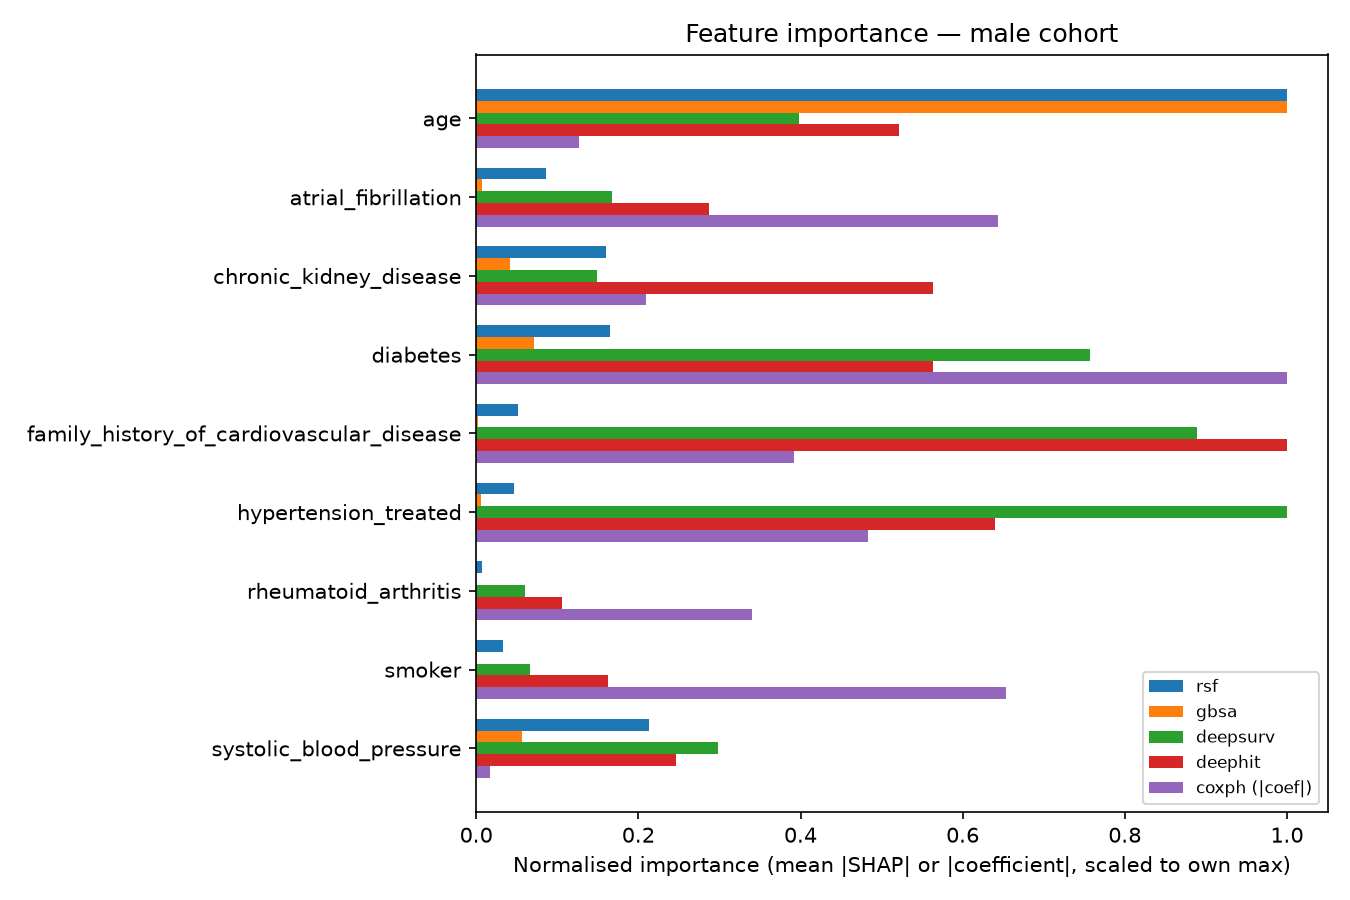


**SHAP summary -- female cohort**

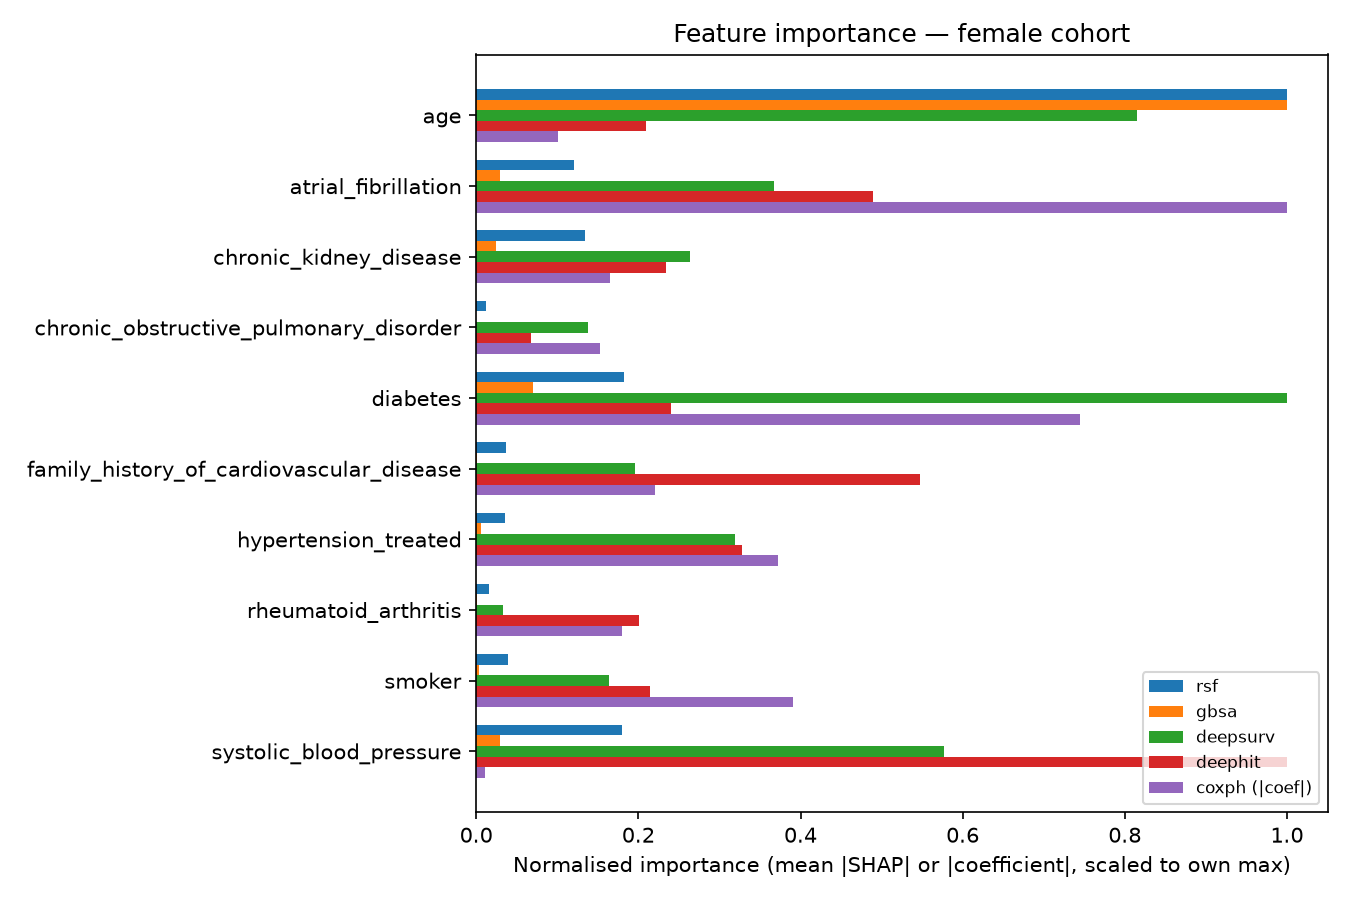


**SHAP dependence (age, systolic BP) -- male cohort**

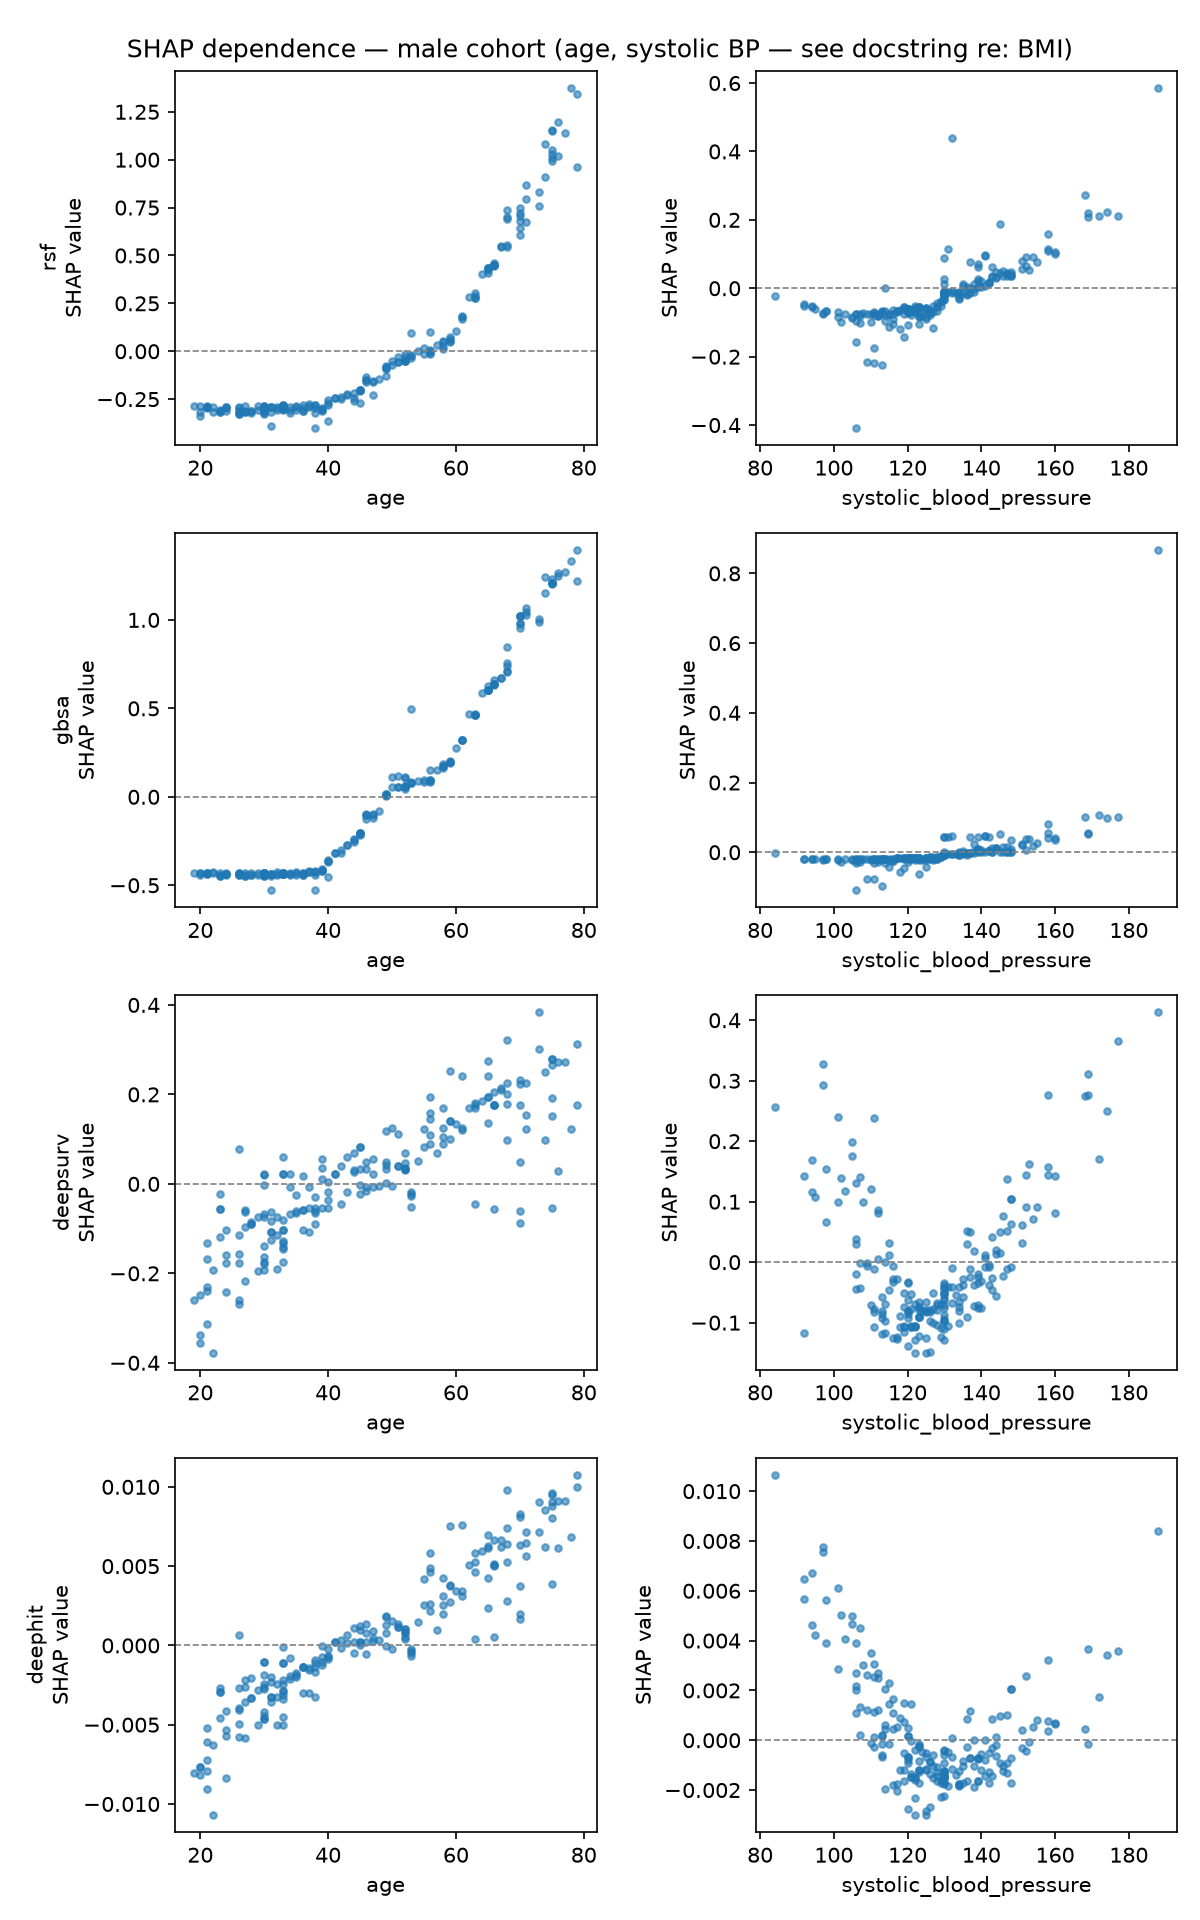


**SHAP dependence (age, systolic BP) -- female cohort**

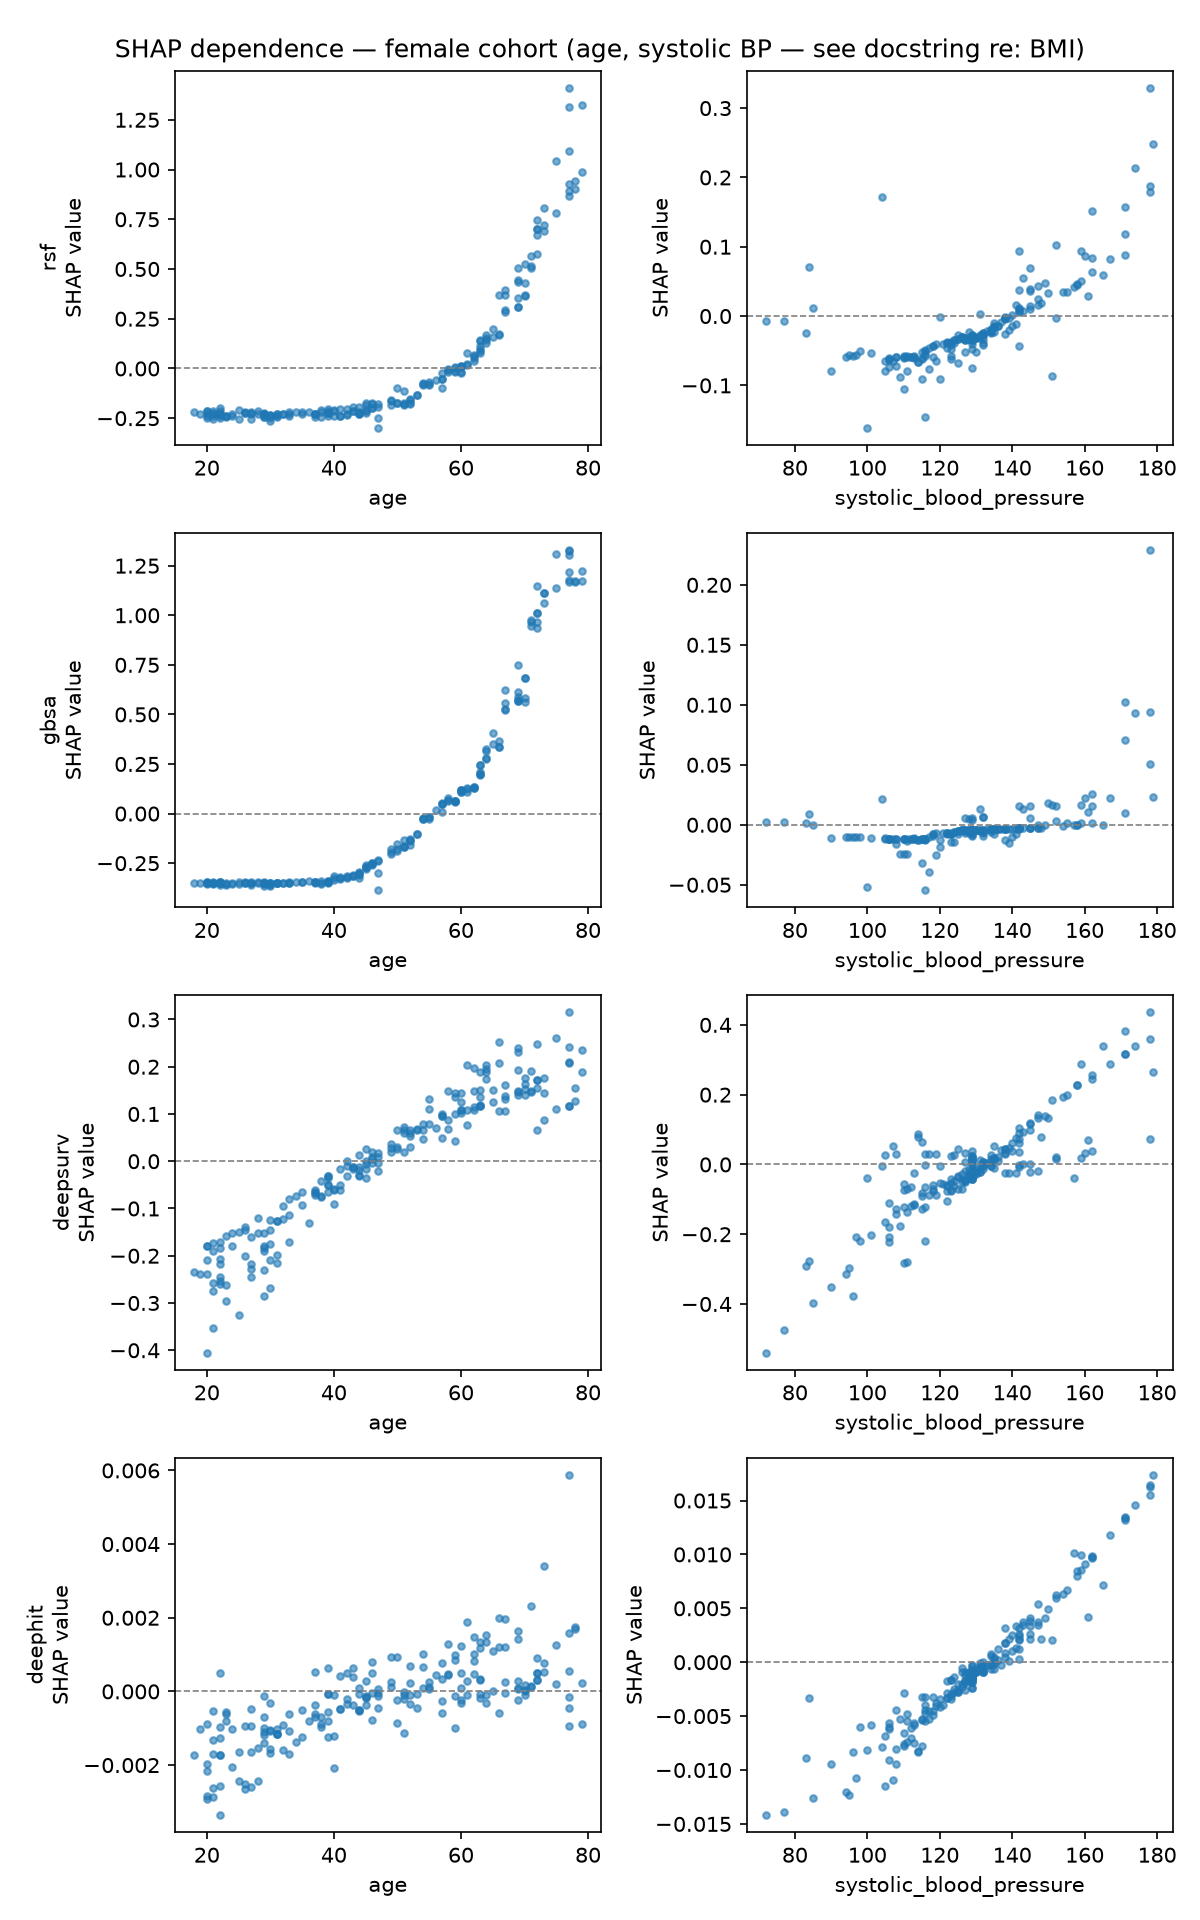


**SHAP rank stability across resampled folds -- male cohort (§9.4)**

| sex | model | predictor | rank_main | rank_resample_1 | rank_resample_2 | rank_range | robust |
| --- | --- | --- | --- | --- | --- | --- | --- |
| male | rsf | age | 1.0000 | 1.0000 | 1.0000 | 0.0000 | True |
| male | rsf | atrial_fibrillation | 5.0000 | 7.0000 | 8.0000 | 3.0000 | False |
| male | rsf | chronic_kidney_disease | 4.0000 | 3.0000 | 4.0000 | 1.0000 | True |
| male | rsf | diabetes | 3.0000 | 4.0000 | 3.0000 | 1.0000 | True |
| male | rsf | family_history_of_cardiovascular_disease | 6.0000 | 5.0000 | 5.0000 | 1.0000 | True |
| male | rsf | hypertension_treated | 7.0000 | 6.0000 | 6.0000 | 1.0000 | True |
| male | rsf | rheumatoid_arthritis | 9.0000 | 9.0000 | 9.0000 | 0.0000 | True |
| male | rsf | smoker | 8.0000 | 8.0000 | 7.0000 | 1.0000 | True |
| male | rsf | systolic_blood_pressure | 2.0000 | 2.0000 | 2.0000 | 0.0000 | True |
| male | gbsa | age | 1.0000 | 1.0000 | 1.0000 | 0.0000 | True |
| male | gbsa | atrial_fibrillation | 5.0000 | 5.0000 | 8.0000 | 3.0000 | False |
| male | gbsa | chronic_kidney_disease | 4.0000 | 4.0000 | 4.0000 | 0.0000 | True |
| male | gbsa | diabetes | 2.0000 | 3.0000 | 3.0000 | 1.0000 | True |
| male | gbsa | family_history_of_cardiovascular_disease | 7.0000 | 8.0000 | 7.0000 | 1.0000 | True |
| male | gbsa | hypertension_treated | 6.0000 | 6.0000 | 5.0000 | 1.0000 | True |
| male | gbsa | rheumatoid_arthritis | 9.0000 | 7.0000 | 9.0000 | 2.0000 | True |
| male | gbsa | smoker | 8.0000 | 9.0000 | 6.0000 | 3.0000 | False |
| male | gbsa | systolic_blood_pressure | 3.0000 | 2.0000 | 2.0000 | 1.0000 | True |
| male | deepsurv | age | 4.0000 | 2.0000 | 1.0000 | 3.0000 | False |
| male | deepsurv | atrial_fibrillation | 6.0000 | 6.0000 | 9.0000 | 3.0000 | False |
| male | deepsurv | chronic_kidney_disease | 7.0000 | 8.0000 | 7.0000 | 1.0000 | True |
| male | deepsurv | diabetes | 3.0000 | 3.0000 | 5.0000 | 2.0000 | True |
| male | deepsurv | family_history_of_cardiovascular_disease | 2.0000 | 5.0000 | 3.0000 | 3.0000 | False |
| male | deepsurv | hypertension_treated | 1.0000 | 7.0000 | 4.0000 | 6.0000 | False |
| male | deepsurv | rheumatoid_arthritis | 9.0000 | 1.0000 | 8.0000 | 8.0000 | False |
| male | deepsurv | smoker | 8.0000 | 9.0000 | 6.0000 | 3.0000 | False |
| male | deepsurv | systolic_blood_pressure | 5.0000 | 4.0000 | 2.0000 | 3.0000 | False |
| male | deephit | age | 5.0000 | 3.0000 | 3.0000 | 2.0000 | True |
| male | deephit | atrial_fibrillation | 6.0000 | 4.0000 | 9.0000 | 5.0000 | False |
| male | deephit | chronic_kidney_disease | 3.0000 | 2.0000 | 6.0000 | 4.0000 | False |
| male | deephit | diabetes | 4.0000 | 6.0000 | 2.0000 | 4.0000 | False |
| male | deephit | family_history_of_cardiovascular_disease | 1.0000 | 5.0000 | 4.0000 | 4.0000 | False |
| male | deephit | hypertension_treated | 2.0000 | 7.0000 | 5.0000 | 5.0000 | False |
| male | deephit | rheumatoid_arthritis | 9.0000 | 9.0000 | 8.0000 | 1.0000 | True |
| male | deephit | smoker | 8.0000 | 8.0000 | 7.0000 | 1.0000 | True |
| male | deephit | systolic_blood_pressure | 7.0000 | 1.0000 | 1.0000 | 6.0000 | False |



**SHAP/LIME top-3 agreement -- male cohort (first 10 of 200 patients; full file in results/tables/)**

| sex | patient_id | rsf_shap_top3 | rsf_lime_top3 | rsf_agreement_count | gbsa_shap_top3 | gbsa_lime_top3 | gbsa_agreement_count | deepsurv_shap_top3 | deepsurv_lime_top3 | deepsurv_agreement_count | deephit_shap_top3 | deephit_lime_top3 | deephit_agreement_count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| male | PT00080143 | age, chronic_kidney_disease, diabetes | age, atrial_fibrillation, diabetes | 2 | age, chronic_kidney_disease, diabetes | age, atrial_fibrillation, diabetes | 2 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00052406 | age, chronic_kidney_disease, diabetes | age, atrial_fibrillation, diabetes | 2 | age, chronic_kidney_disease, diabetes | age, chronic_kidney_disease, diabetes | 3 | age, diabetes, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | age, chronic_kidney_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 0 |
| male | PT00051887 | age, chronic_kidney_disease, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 1 | age, diabetes, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 2 | diabetes, hypertension_treated, systolic_blood_pressure | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | diabetes, family_history_of_cardiovascular_disease, systolic_blood_pressure | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00038726 | age, chronic_kidney_disease, family_history_of_cardiovascular_disease | age, atrial_fibrillation, diabetes | 1 | age, chronic_kidney_disease, diabetes | age, chronic_kidney_disease, diabetes | 3 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00074281 | age, chronic_kidney_disease, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 1 | age, chronic_kidney_disease, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 1 | age, chronic_kidney_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 1 | age, chronic_kidney_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 0 |
| male | PT00036351 | age, chronic_kidney_disease, diabetes | atrial_fibrillation, chronic_kidney_disease, diabetes | 2 | age, chronic_kidney_disease, diabetes | age, atrial_fibrillation, diabetes | 2 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | chronic_kidney_disease, family_history_of_cardiovascular_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 0 |
| male | PT00017450 | age, diabetes, family_history_of_cardiovascular_disease | atrial_fibrillation, chronic_kidney_disease, diabetes | 1 | age, chronic_kidney_disease, diabetes | age, chronic_kidney_disease, diabetes | 3 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | diabetes, family_history_of_cardiovascular_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00068257 | age, diabetes, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 2 | age, diabetes, systolic_blood_pressure | age, diabetes, rheumatoid_arthritis | 2 | chronic_kidney_disease, diabetes, family_history_of_cardiovascular_disease | diabetes, hypertension_treated, rheumatoid_arthritis | 1 | age, diabetes, family_history_of_cardiovascular_disease | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00035602 | age, chronic_kidney_disease, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 1 | age, diabetes, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 2 | diabetes, hypertension_treated, systolic_blood_pressure | diabetes, hypertension_treated, rheumatoid_arthritis | 2 | diabetes, family_history_of_cardiovascular_disease, systolic_blood_pressure | atrial_fibrillation, diabetes, rheumatoid_arthritis | 1 |
| male | PT00015738 | age, chronic_kidney_disease, systolic_blood_pressure | age, atrial_fibrillation, diabetes | 1 | age, chronic_kidney_disease, systolic_blood_pressure | age, chronic_kidney_disease, diabetes | 2 | age, chronic_kidney_disease, hypertension_treated | diabetes, hypertension_treated, rheumatoid_arthritis | 1 | age, chronic_kidney_disease, hypertension_treated | atrial_fibrillation, diabetes, rheumatoid_arthritis | 0 |


*(showing first 10 of 200 rows -- full file at `results/tables/stage8_shap_lime_agreement_male.csv`)*


---
## Stage 9 -- Results Dashboard (GitHub Pages build)

Added beyond the original §11 8-stage layout (documented in CLAUDE.md §15.5). Reads the actual Stage 3/7/8 output tables and renders the static dashboard to `docs/index.html` -- no figures of its own beyond copying the ones already produced above.


In [ ]:
"""Stage 9 (added beyond the original §11 8-stage layout, per the user's deployment request —
see CLAUDE.md §15.5/§17) — builds the static results dashboard for GitHub Pages.

Reads the actual Stage 3/7/8 output tables (never hand-transcribed) and renders a single
static HTML page to `docs/index.html`, with the Stage 4/7/8 figures copied to `docs/figures/`.
GitHub Pages serves static files only, so this is plain HTML/CSS — no server, no framework,
no external requests (self-contained, works offline once downloaded).

Design follows the project's dataviz skill: system-sans typography, tabular-nums for the
results table, light/dark mode via `prefers-color-scheme` (not a click toggle — there's no
viewer chrome on a static page to host one), and significance is marked by bold text + a
footnote symbol rather than colour alone (a 95% CI excluding zero is the only thing flagged
this way — deliberately not framed as "good/bad" with a status colour, since a non-significant
difference is itself one of this project's genuine findings, not a failure state).
"""

import shutil
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path(__file__).resolve().parent.parent
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_FIGURES = DOCS_DIR / "figures"

REPO_URL = "https://github.com/nwereonyerex-sudo/Survival-Based-ML"

MODEL_ORDER = ["coxph", "qrisk3_style", "rsf", "gbsa", "deepsurv", "deephit"]
MODEL_DISPLAY = {
    "coxph": "CoxPH",
    "qrisk3_style": "QRISK3-style",
    "rsf": "Random Survival Forest",
    "gbsa": "Gradient-Boosting Survival",
    "deepsurv": "DeepSurv",
    "deephit": "DeepHit",
}
SEX_ORDER = ["male", "female"]
SEX_DISPLAY = {"male": "Male cohort", "female": "Female cohort"}
FIGURES = [
    ("km_curve", "Kaplan–Meier survival (descriptive)"),
    ("calibration", "Calibration — decile-grouped, observed vs predicted 10-year risk"),
    ("shap_summary", "SHAP global feature importance, compared to CoxPH coefficients"),
    ("shap_dependence", "SHAP dependence — age and systolic blood pressure"),
]


def fmt(x: float, decimals: int = 3) -> str:
    return f"{x:.{decimals}f}"


def ci_excludes_zero(low: float, high: float) -> bool:
    return not (low <= 0 <= high)


def build_results_rows(summary: pd.DataFrame) -> str:
    rows = []
    for sex in SEX_ORDER:
        rows.append(f'<tr class="sex-header"><td colspan="4">{SEX_DISPLAY[sex]}</td></tr>')
        sub = summary[summary["sex"] == sex].set_index("model")
        for model in MODEL_ORDER:
            r = sub.loc[model]
            cindex_cell = f"{fmt(r['cindex'])} ({fmt(r['cindex_ci_low'])}–{fmt(r['cindex_ci_high'])})"
            uno_cell = f"{fmt(r['uno_cindex'])} ({fmt(r['uno_cindex_ci_low'])}–{fmt(r['uno_cindex_ci_high'])})"
            brier_suffix = "" if r["brier_score_type"] == "integrated" else "¹"
            brier_cell = f"{fmt(r['brier'], 4)} ({fmt(r['brier_ci_low'], 4)}–{fmt(r['brier_ci_high'], 4)}){brier_suffix}"

            if model in ("coxph", "qrisk3_style"):
                delta_cell = "— (baseline)"
            else:
                sig = ci_excludes_zero(r["delta_cindex_vs_coxph_ci_low"],
                                        r["delta_cindex_vs_coxph_ci_high"])
                sign = "+" if r["delta_cindex_vs_coxph"] >= 0 else ""
                marker = " †" if sig else ""
                cls = " class=\"significant\"" if sig else ""
                delta_cell = (f"<span{cls}>{sign}{fmt(r['delta_cindex_vs_coxph'])} vs CoxPH"
                               f"{marker}</span>")

            rows.append(
                "<tr>"
                f"<td>{MODEL_DISPLAY[model]}</td>"
                f"<td class=\"num\">{cindex_cell}</td>"
                f"<td class=\"num\">{uno_cell}</td>"
                f"<td class=\"num\">{brier_cell}</td>"
                "</tr>"
            )
            # second row: delta vs baselines, spans under the metrics for readability
            rows.append(
                f'<tr class="delta-row"><td></td><td colspan="3" class="num delta">'
                f'{delta_cell}</td></tr>'
            )
    return "\n".join(rows)


def build_feature_set_html(sex: str) -> str:
    df = pd.read_csv(RESULTS_TABLES / f"stage3_feature_selection_{sex}.csv")
    kept = sorted(df.loc[df["final_selected_feature_set"], "predictor"].tolist())
    items = "".join(f"<li>{p.replace('_', ' ')}</li>" for p in kept)
    return f"<ul class=\"feature-list\">{items}</ul>"


def compute_explainability_stats() -> dict:
    stats = {}
    for sex in SEX_ORDER:
        stability = pd.read_csv(RESULTS_TABLES / f"stage8_stability_{sex}.csv")
        agreement = pd.read_csv(RESULTS_TABLES / f"stage8_shap_lime_agreement_{sex}.csv")
        for model in ["rsf", "gbsa", "deepsurv", "deephit"]:
            n_total = (stability["model"] == model).sum()
            n_unstable = ((stability["model"] == model) & (~stability["robust"])).sum()
            mean_agree = agreement[f"{model}_agreement_count"].mean()
            stats[(sex, model)] = {
                "n_unstable": int(n_unstable), "n_total": int(n_total),
                "mean_agree": mean_agree,
            }
    return stats


def build_stability_summary_html(stats: dict) -> str:
    rows = []
    for sex in SEX_ORDER:
        cells = []
        for model in ["rsf", "gbsa", "deepsurv", "deephit"]:
            s = stats[(sex, model)]
            cells.append(
                f"<td>{MODEL_DISPLAY[model]}: <strong>{s['n_unstable']}/{s['n_total']}</strong> "
                f"unstable, top-3 overlap <strong>{s['mean_agree']:.2f}/3</strong></td>"
            )
        rows.append(f"<tr><td>{SEX_DISPLAY[sex]}</td>{''.join(cells)}</tr>")
    return "\n".join(rows)


def copy_figures() -> None:
    DOCS_FIGURES.mkdir(parents=True, exist_ok=True)
    for prefix, _ in FIGURES:
        for sex in SEX_ORDER:
            src = RESULTS_FIGURES / f"{prefix}_{sex}.png"
            if not src.exists():
                raise FileNotFoundError(f"{src} not found — run the full pipeline first.")
            shutil.copy2(src, DOCS_FIGURES / src.name)


def figure_section_html() -> str:
    sections = []
    for prefix, title in FIGURES:
        cards = "".join(
            f'<figure><img src="figures/{prefix}_{sex}.png" alt="{title} — {sex}">'
            f'<figcaption>{SEX_DISPLAY[sex]}</figcaption></figure>'
            for sex in SEX_ORDER
        )
        sections.append(f'<h3>{title}</h3><div class="figure-row">{cards}</div>')
    return "\n".join(sections)


PAGE_TEMPLATE = """<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Survival-Based ML for 10-Year CVD Risk</title>
<style>
:root {{
  color-scheme: light;
  --page: #f9f9f7;
  --surface: #fcfcfb;
  --text-primary: #0b0b0b;
  --text-secondary: #52514e;
  --text-muted: #898781;
  --gridline: #e1e0d9;
  --border: rgba(11,11,11,0.10);
  --accent: #2a78d6;
  --risk-low: #2f7d52;
  --risk-moderate: #a66a1e;
  --risk-high: #b03a26;
}}
@media (prefers-color-scheme: dark) {{
  :root {{
    color-scheme: dark;
    --page: #0d0d0d;
    --surface: #1a1a19;
    --text-primary: #ffffff;
    --text-secondary: #c3c2b7;
    --text-muted: #898781;
    --gridline: #2c2c2a;
    --border: rgba(255,255,255,0.10);
    --accent: #3987e5;
    --risk-low: #5fbf87;
    --risk-moderate: #d9a652;
    --risk-high: #d9694a;
  }}
}}
* {{ box-sizing: border-box; }}
body {{
  margin: 0;
  background: var(--page);
  color: var(--text-primary);
  font-family: system-ui, -apple-system, "Segoe UI", sans-serif;
  line-height: 1.55;
}}
.wrap {{ max-width: 920px; margin: 0 auto; padding: 2.5rem 1.25rem 5rem; }}
header.hero {{ margin-bottom: 2.5rem; }}
.eyebrow {{
  display: flex; align-items: center; gap: 0.5rem; font-size: 0.78rem; letter-spacing: 0.06em;
  text-transform: uppercase; color: var(--accent); margin: 0 0 0.6rem;
}}
.pulse-icon {{ width: 28px; height: auto; color: var(--accent); flex: none; }}
h1 {{ font-size: 1.9rem; margin: 0 0 0.4rem; }}
.subtitle {{ color: var(--text-secondary); font-size: 1.05rem; margin: 0 0 1rem; }}
.repo-link {{ font-size: 0.9rem; }}
.repo-link a {{ color: var(--accent); text-decoration: none; }}
.repo-link a:hover {{ text-decoration: underline; }}
section {{ margin: 3rem 0; }}
h2 {{
  font-size: 1.3rem; border-bottom: 1px solid var(--gridline);
  padding-bottom: 0.5rem; margin-bottom: 1rem;
}}
h3 {{ font-size: 1.05rem; color: var(--text-secondary); margin: 1.75rem 0 0.75rem; }}
p {{ color: var(--text-secondary); }}
.ethics {{
  background: var(--surface); border: 1px solid var(--border); border-radius: 8px;
  padding: 1rem 1.25rem; font-size: 0.92rem;
}}
table {{ width: 100%; border-collapse: collapse; font-size: 0.9rem; }}
th {{
  text-align: left; font-size: 0.78rem; text-transform: uppercase; letter-spacing: 0.03em;
  color: var(--text-muted); border-bottom: 1px solid var(--gridline); padding: 0.5rem 0.6rem;
}}
td {{ padding: 0.45rem 0.6rem; border-bottom: 1px solid var(--gridline); vertical-align: top; }}
td.num {{ font-variant-numeric: tabular-nums; }}
tr.sex-header td {{
  padding-top: 1.5rem; font-weight: 600; border-bottom: 1px solid var(--text-muted);
  color: var(--text-primary);
}}
tr.delta-row td {{ border-bottom: 1px solid var(--gridline); padding-top: 0; color: var(--text-muted); font-size: 0.85rem; }}
td.delta {{ text-align: left; }}
span.significant {{ font-weight: 600; color: var(--text-primary); }}
.legend {{ font-size: 0.82rem; color: var(--text-muted); margin-top: 0.6rem; }}
.feature-list {{ columns: 2; column-gap: 2rem; font-size: 0.9rem; color: var(--text-secondary); }}
.figure-row {{ display: flex; gap: 1rem; flex-wrap: wrap; }}
figure {{
  margin: 0; flex: 1 1 380px; background: #ffffff; border: 1px solid var(--border);
  border-radius: 8px; padding: 0.6rem; text-align: center;
}}
figure img {{ max-width: 100%; height: auto; border-radius: 4px; }}
figcaption {{ font-size: 0.8rem; color: #52514e; margin-top: 0.4rem; }}
.stability-table td {{ font-size: 0.85rem; }}
.findings li {{ margin-bottom: 0.9rem; color: var(--text-secondary); }}
footer {{
  margin-top: 4rem; padding-top: 1.5rem; border-top: 1px solid var(--gridline);
  font-size: 0.85rem; color: var(--text-muted);
}}
footer a {{ color: var(--accent); }}
code {{ font-size: 0.85em; background: var(--surface); padding: 0.1em 0.35em; border-radius: 4px; }}
{calculator_css}
</style>
</head>
<body>
<div class="wrap">

<header class="hero">
  <p class="eyebrow">
    <svg class="pulse-icon" viewBox="0 0 64 24" aria-hidden="true"><path d="M1 12 H20 L25 2 L32 22 L37 12 H63" fill="none" stroke="currentColor" stroke-width="3" stroke-linecap="round" stroke-linejoin="round"/></svg>
    Sex-stratified survival modelling
  </p>
  <h1>Survival-Based ML for 10-Year Heart Attack/Stroke Risk</h1>
  <p class="subtitle">Benchmarking six sex-stratified survival models — CoxPH, a
  QRISK3-style clinical score, Random Survival Forest, Gradient-Boosting Survival Analysis,
  DeepSurv, and DeepHit — on discrimination, calibration, and explainability.</p>
  <p class="repo-link"><a href="{repo_url}">{repo_url}</a></p>
</header>

<section id="ethics">
  <div class="ethics">
    <strong>Data and ethics.</strong> Trained and evaluated exclusively on
    Burns, Richardson and Driessens (2024)'s CC0-licensed, 100%-synthetic primary-care
    dataset (doi: 10.3310/nihropenres.13651.1). No real, identifiable, or non-synthetic
    patient data was used at any stage.
  </div>
</section>

<section id="results">
  <h2>Results — six models × two sexes</h2>
  <p>Harrell's C-index and Uno's IPCW C-statistic (discrimination), and the Brier score
  (calibration), all with bootstrap 95% confidence intervals from 1,000 resamples of the held-out
  test set. The row beneath each model shows its effect size vs. the sex-specific CoxPH
  baseline.</p>
  <table>
    <thead>
      <tr><th>Model</th><th>C-index (95% CI)</th><th>Uno's C (95% CI)</th><th>Brier score (95% CI)</th></tr>
    </thead>
    <tbody>
{results_rows}
    </tbody>
  </table>
  <p class="legend">† 95% CI on the delta excludes zero (statistically distinguishable
  from the CoxPH baseline). ¹ QRISK3-style is a fixed single-horizon clinical formula, not
  a fitted survival model — its Brier score is evaluated at a single ~10-year timepoint,
  not integrated over the full follow-up like the other five models.</p>
</section>

<section id="features">
  <h2>Selected predictors per sex</h2>
  <p>Feature selection (multicollinearity screening + validation-tuned LASSO) ran
  independently per sex; the surviving set is used identically across CoxPH, RSF, GBSA,
  DeepSurv, and DeepHit for that sex. QRISK3-style uses its own fixed clinical predictor set
  regardless.</p>
  <h3>{male_label}</h3>
  {male_features}
  <h3>{female_label}</h3>
  {female_features}
</section>

{calculator_section}

<section id="figures">
  <h2>Descriptive survival, calibration, and explainability</h2>
{figure_sections}
</section>

<section id="stability">
  <h2>SHAP stability and SHAP/LIME agreement</h2>
  <p>Unstable = the predictor's SHAP-importance rank shifted by more than 2 positions across
  two independent bootstrap resamples of the training fold. Top-3 overlap = mean count of
  shared features between each patient's top-3 SHAP and top-3 LIME features (out of 3).</p>
  <table class="stability-table">
    <tbody>
{stability_rows}
    </tbody>
  </table>
</section>

<section id="findings">
  <h2>Notable findings</h2>
  <ul class="findings">
    <li><strong>QRISK3-style leads discrimination but is clearly the worst-calibrated model,
    in both sexes.</strong> Its C-index point estimate is highest in both sexes, and its
    Brier score's 95% CI does not overlap any of the other five models' in either sex — a
    genuine discrimination/calibration split, not sampling noise. The discrimination
    advantage itself is only statistically significant for males, though — for females the
    same comparison's confidence interval touches zero.</li>
    <li><strong>CoxPH is a hard baseline to beat: none of the four fitted ML/DL models
    significantly improves on it, and several significantly underperform it.</strong> RSF,
    GBSA, DeepSurv, and DeepHit never show a statistically significant <em>improvement</em>
    over CoxPH on any metric, in either sex — but for males, GBSA and DeepHit calibrate
    significantly <em>worse</em>; for females, RSF, GBSA, and DeepHit all discriminate
    significantly worse. DeepSurv is the only one of the four that never differs
    significantly from CoxPH on any metric, in either sex.</li>
    <li><strong>Tree ensembles concentrate importance on age; CoxPH and the deep models
    spread it across comorbidities.</strong> RSF and GBSA's SHAP importance is dominated by
    age alone; CoxPH's coefficients and DeepSurv/DeepHit's SHAP values distribute more evenly
    across diabetes, atrial fibrillation, family history, and treated hypertension —
    consistent in both sexes.</li>
    <li><strong>DeepSurv and DeepHit's explanations are considerably less stable than
    RSF/GBSA's, despite similar predictive performance.</strong> The majority of predictors
    for the two deep models shift rank materially across resampled training folds, and their
    SHAP/LIME agreement is markedly lower — a real explainability-vs-performance tradeoff,
    not visible from C-index alone.</li>
  </ul>
</section>

<footer>
  Full methodology, every resolved spec deviation, and the complete stage-by-stage
  implementation journal: see <a href="{repo_url}/blob/main/CLAUDE.md">CLAUDE.md</a> and
  <a href="{repo_url}/blob/main/journal/agent_journal.md">journal/agent_journal.md</a> in the
  repository. Built from the pipeline's own output tables — not hand-transcribed.
</footer>

</div>
</body>
</html>
"""

# --- QRISK3-style calculator (client-side demo of §7's rebuild) --------------------------
# The in-browser port must match src/04_baselines.py's qrisk3_style_score() exactly — validated
# against it on 4 hand-picked cases (both sexes, low/high risk) via Node, matching to 6 decimal
# places before this was written into the page.
CALCULATOR_CSS = """
.calc-card { background: var(--surface); border: 1px solid var(--border); border-radius: 10px; padding: 1.5rem 1.75rem; }
.warn-box { display: flex; gap: 0.9rem; align-items: flex-start; background: rgba(166,106,30,0.08); border: 1px solid rgba(166,106,30,0.35); border-radius: 8px; padding: 1rem 1.15rem; margin: 0 0 1.5rem; }
.warn-icon { width: 20px; height: 20px; flex: none; margin-top: 0.15rem; color: var(--risk-moderate); }
.warn-title { font-weight: 600; font-size: 0.95rem; color: var(--text-primary); margin: 0 0 0.5rem; }
.warn-list { margin: 0; padding-left: 1.1rem; font-size: 0.85rem; color: var(--text-secondary); }
.warn-list li { margin-bottom: 0.35rem; }
.warn-list li:last-child { margin-bottom: 0; }
.calc-grid { display: grid; grid-template-columns: 1.1fr 1fr; gap: 2rem; align-items: start; }
@media (max-width: 720px) { .calc-grid { grid-template-columns: 1fr; } }
.field-group { margin-bottom: 1.3rem; }
.field-label { display: block; font-size: 0.72rem; letter-spacing: 0.03em; text-transform: uppercase; color: var(--text-muted); margin-bottom: 0.5rem; }
.seg-control { display: inline-flex; border: 1px solid var(--border); border-radius: 8px; overflow: hidden; }
.seg-control button { font: inherit; font-weight: 600; font-size: 0.9rem; padding: 0.45rem 1.15rem; border: none; background: var(--page); color: var(--text-secondary); cursor: pointer; }
.seg-control button + button { border-left: 1px solid var(--border); }
.seg-control button[aria-pressed="true"] { background: var(--accent); color: #ffffff; }
.num-row { display: flex; gap: 1rem; flex-wrap: wrap; }
.num-field { flex: 1 1 130px; font-size: 0.85rem; color: var(--text-secondary); }
.num-field input { width: 100%; font: inherit; font-variant-numeric: tabular-nums; padding: 0.5rem 0.6rem; border: 1px solid var(--border); border-radius: 6px; background: var(--page); color: var(--text-primary); margin-top: 0.3rem; }
.num-field span.unit { font-size: 0.75rem; color: var(--text-muted); }
.chip-grid { display: flex; flex-wrap: wrap; gap: 0.5rem; }
.chip { font: inherit; font-size: 0.83rem; padding: 0.4rem 0.8rem; border: 1px solid var(--border); border-radius: 999px; background: var(--page); color: var(--text-secondary); cursor: pointer; }
.chip[aria-pressed="true"] { background: var(--accent); border-color: var(--accent); color: #ffffff; }
.gauge-panel { display: flex; flex-direction: column; align-items: center; }
.gauge-svg { width: 100%; max-width: 260px; }
.gauge-track-low { stroke: var(--risk-low); opacity: 0.35; }
.gauge-track-moderate { stroke: var(--risk-moderate); opacity: 0.35; }
.gauge-track-high { stroke: var(--risk-high); opacity: 0.35; }
.gauge-needle { stroke: var(--text-primary); transition: transform 0.4s ease; transform-origin: 120px 120px; }
.gauge-hub { fill: var(--text-primary); }
.gauge-readout { text-align: center; margin-top: -2rem; }
.gauge-value { font-weight: 700; font-size: 2rem; font-variant-numeric: tabular-nums; display: block; color: var(--text-primary); }
.gauge-sub { font-size: 0.78rem; color: var(--text-muted); }
.risk-pill { display: inline-block; margin-top: 0.6rem; padding: 0.25rem 0.8rem; border-radius: 999px; font-size: 0.75rem; font-weight: 600; letter-spacing: 0.02em; text-transform: uppercase; }
.risk-pill.low { background: rgba(47,125,82,0.15); color: var(--risk-low); }
.risk-pill.moderate { background: rgba(166,106,30,0.15); color: var(--risk-moderate); }
.risk-pill.high { background: rgba(176,58,38,0.15); color: var(--risk-high); }
.gauge-explainer { font-size: 0.78rem; color: var(--text-secondary); text-align: center; margin-top: 0.9rem; max-width: 28ch; }
.gauge-caveat { font-size: 0.78rem; color: var(--text-muted); text-align: center; margin-top: 0.6rem; max-width: 28ch; }
.gauge-caveat.is-warning { color: var(--risk-moderate); font-weight: 600; }
@media (prefers-reduced-motion: reduce) { .gauge-needle { transition: none; } }
"""

CALCULATOR_SECTION = """
<section id="try-it">
  <h2>Try the QRISK3-style instrument</h2>
  <p>This reproduces, in-browser, the exact scoring function used as one of the six baselines
  above — the same coefficients, the same fixed inputs, computed the same way as
  <code>src/04_baselines.py</code>'s <code>qrisk3_style_score()</code>. It's the only one of
  the six models that can run client-side: RSF, GBSA, DeepSurv, and DeepHit are fitted
  Python/PyTorch models, not portable formulas.</p>
  <div class="calc-card">
    <div class="warn-box" role="note">
      <svg class="warn-icon" viewBox="0 0 24 24" aria-hidden="true"><path d="M12 3 L22 20 H2 Z" fill="none" stroke="currentColor" stroke-width="1.6" stroke-linejoin="round"/><line x1="12" y1="9.5" x2="12" y2="14" stroke="currentColor" stroke-width="1.6" stroke-linecap="round"/><circle cx="12" cy="16.8" r="1" fill="currentColor"/></svg>
      <div>
        <p class="warn-title">Not a clinical instrument — read before you try it</p>
        <ul class="warn-list">
          <li>This is a research demonstration on a 100% synthetic-data thesis project. Do not use it to make real medical decisions — speak to a clinician instead.</li>
          <li>It shows only the QRISK3-style formula, one of the six models compared above — not the project's best-performing or final model.</li>
          <li>QRISK3 is validated for ages 25–84 only. Outside that range the score extrapolates and can saturate at exactly 100 — a known, documented edge case, not a bug.</li>
          <li>Cholesterol/HDL ratio is fixed at 3 and blood-pressure variability at 10 mmHg for every input, per the project's rebuild rules — the calculator does not ask for them.</li>
        </ul>
      </div>
    </div>
    <div class="calc-grid">
      <div class="calc-inputs">
        <div class="field-group">
          <span class="field-label">Sex</span>
          <div class="seg-control" role="group" aria-label="Sex">
            <button type="button" data-sex="male" aria-pressed="true">Male</button>
            <button type="button" data-sex="female" aria-pressed="false">Female</button>
          </div>
        </div>
        <div class="field-group">
          <span class="field-label">Measurements</span>
          <div class="num-row">
            <label class="num-field">Age <span class="unit">(years)</span>
              <input type="number" id="in-age" min="18" max="100" value="55" inputmode="numeric">
            </label>
            <label class="num-field">BMI <span class="unit">(kg/m&sup2;)</span>
              <input type="number" id="in-bmi" min="12" max="60" step="0.1" value="27" inputmode="decimal">
            </label>
            <label class="num-field">Systolic BP <span class="unit">(mmHg)</span>
              <input type="number" id="in-sbp" min="70" max="240" value="130" inputmode="numeric">
            </label>
          </div>
        </div>
        <div class="field-group">
          <span class="field-label">Conditions &amp; history</span>
          <div class="chip-grid">
            <button type="button" class="chip" data-field="smoker" aria-pressed="false">Smoker</button>
            <button type="button" class="chip" data-field="diabetes" aria-pressed="false">Diabetes</button>
            <button type="button" class="chip" data-field="atrial_fibrillation" aria-pressed="false">Atrial fibrillation</button>
            <button type="button" class="chip" data-field="hypertension_treated" aria-pressed="false">Hypertension (treated)</button>
            <button type="button" class="chip" data-field="chronic_kidney_disease" aria-pressed="false">Chronic kidney disease</button>
            <button type="button" class="chip" data-field="rheumatoid_arthritis" aria-pressed="false">Rheumatoid arthritis</button>
            <button type="button" class="chip" data-field="family_history_of_cardiovascular_disease" aria-pressed="false">Family history of CVD</button>
          </div>
        </div>
      </div>
      <div class="gauge-panel">
        <svg class="gauge-svg" viewBox="0 0 240 150" aria-hidden="true">
          <path id="track-low" class="gauge-track-low" fill="none" stroke-width="14" stroke-linecap="round"></path>
          <path id="track-moderate" class="gauge-track-moderate" fill="none" stroke-width="14" stroke-linecap="round"></path>
          <path id="track-high" class="gauge-track-high" fill="none" stroke-width="14" stroke-linecap="round"></path>
          <line id="needle" class="gauge-needle" x1="120" y1="120" x2="120" y2="34" stroke-width="3" stroke-linecap="round"></line>
          <circle class="gauge-hub" cx="120" cy="120" r="6"></circle>
        </svg>
        <div class="gauge-readout">
          <span class="gauge-value" id="out-score">—</span>
          <span class="gauge-sub">10-year risk</span>
          <div><span class="risk-pill low" id="out-pill">—</span></div>
        </div>
        <p class="gauge-explainer">Updates instantly as you change anything on the left. Higher
        age, higher blood pressure, and each added condition raise this number; removing them
        brings it back down — nothing is added up or remembered between changes.</p>
        <p class="gauge-caveat" id="out-caveat"></p>
      </div>
    </div>
  </div>
</section>

<script>
(function () {
  "use strict";

  var QRISK3_SURVIVOR_10Y = { female: 0.988876402378082, male: 0.977268040180206 };
  var QRISK3_ISMOKE_LIGHT = { female: 0.13386833786546262, male: 0.19128222863388983 };
  var FIXED_CHOLESTEROL_HDL_RATIO = 3.0;
  var FIXED_SBP_SD = 10.0;

  function qrisk3StyleScore(row, sexLabel) {
    var ageScaled = row.age / 10.0;
    var bmiScaled = row.body_mass_index / 10.0;
    var sbp = row.systolic_blood_pressure;
    var smokeLight = row.smoker ? 1 : 0;
    var diabetesType2 = row.diabetes ? 1 : 0;
    var a, survivor;

    if (sexLabel === "female") {
      var age1 = Math.pow(ageScaled, -2) - 0.053274843841791;
      var age2 = ageScaled - 4.332503318786621;
      var bmi1 = Math.pow(bmiScaled, -2) - 0.154946178197861;
      var bmi2 = Math.pow(bmiScaled, -2) * Math.log(bmiScaled) - 0.144462317228317;
      var rati = FIXED_CHOLESTEROL_HDL_RATIO - 3.476326465606690;
      var sbpC = sbp - 123.130012512207030;
      var sbps5 = FIXED_SBP_SD - 9.002537727355957;

      a = QRISK3_ISMOKE_LIGHT.female * smokeLight;
      a += age1 * -8.1388109247726188 + age2 * 0.79733376689699098;
      a += bmi1 * 0.29236092275460052 + bmi2 * -4.1513300213837665;
      a += rati * 0.15338035820802554 + sbpC * 0.013131488407103424;
      a += sbps5 * 0.0078894541014586095;
      a += (row.atrial_fibrillation ? 1 : 0) * 1.5923354969269663;
      a += (row.rheumatoid_arthritis ? 1 : 0) * 0.21364803435181942;
      a += (row.chronic_kidney_disease ? 1 : 0) * 0.65194569493845833;
      a += (row.hypertension_treated ? 1 : 0) * 0.50931593683423004;
      a += diabetesType2 * 1.0688773244615468;
      a += (row.family_history_of_cardiovascular_disease ? 1 : 0) * 0.45445319020896213;
      a += age1 * smokeLight * -4.7057161785851891;
      a += age1 * (row.atrial_fibrillation ? 1 : 0) * 19.938034889546561;
      a += age1 * (row.chronic_kidney_disease ? 1 : 0) * -3.5874047731694114;
      a += age1 * (row.hypertension_treated ? 1 : 0) * 11.872809733921812;
      a += age1 * diabetesType2 * 6.8652342000009599;
      a += age1 * bmi1 * 23.802623412141742 + age1 * bmi2 * -71.184947692087007;
      a += age1 * (row.family_history_of_cardiovascular_disease ? 1 : 0) * 0.99467807940435127;
      a += age1 * sbpC * 0.034131842338615485;
      a += age2 * smokeLight * -0.075589244643193026;
      a += age2 * (row.atrial_fibrillation ? 1 : 0) * -0.076182651011162505;
      a += age2 * (row.chronic_kidney_disease ? 1 : 0) * -0.22688873086442507;
      a += age2 * (row.hypertension_treated ? 1 : 0) * 0.00096857823588174436;
      a += age2 * diabetesType2 * -0.097112252590695489;
      a += age2 * bmi1 * 0.52369958933664429 + age2 * bmi2 * 0.045744190122323759;
      a += age2 * (row.family_history_of_cardiovascular_disease ? 1 : 0) * -0.076885051698423038;
      a += age2 * sbpC * -0.0015082501423272358;
      survivor = QRISK3_SURVIVOR_10Y.female;
    } else {
      var mage1 = Math.pow(ageScaled, -1) - 0.234766781330109;
      var mage2 = Math.pow(ageScaled, 3) - 77.284080505371094;
      var mbmi1 = Math.pow(bmiScaled, -2) - 0.149176135659218;
      var mbmi2 = Math.pow(bmiScaled, -2) * Math.log(bmiScaled) - 0.141913309693336;
      var mrati = FIXED_CHOLESTEROL_HDL_RATIO - 4.300998687744141;
      var msbpC = sbp - 128.571578979492190;
      var msbps5 = FIXED_SBP_SD - 8.756621360778809;

      a = QRISK3_ISMOKE_LIGHT.male * smokeLight;
      a += mage1 * -17.839781666005575 + mage2 * 0.0022964880605765492;
      a += mbmi1 * 2.4562776660536358 + mbmi2 * -8.3011122314711354;
      a += mrati * 0.17340196856327111 + msbpC * 0.012910126542553305;
      a += msbps5 * 0.010251914291290456;
      a += (row.atrial_fibrillation ? 1 : 0) * 0.88209236928054657;
      a += (row.rheumatoid_arthritis ? 1 : 0) * 0.20970658013956567;
      a += (row.chronic_kidney_disease ? 1 : 0) * 0.71853261288274384;
      a += (row.hypertension_treated ? 1 : 0) * 0.51659871082695474;
      a += diabetesType2 * 0.85942071430932221;
      a += (row.family_history_of_cardiovascular_disease ? 1 : 0) * 0.54055469009390156;
      a += mage1 * smokeLight * -0.21011133933516346;
      a += mage1 * (row.atrial_fibrillation ? 1 : 0) * 3.4896675530623207;
      a += mage1 * (row.chronic_kidney_disease ? 1 : 0) * -0.50656716327223694;
      a += mage1 * (row.hypertension_treated ? 1 : 0) * 6.5114581098532671;
      a += mage1 * diabetesType2 * 3.6461817406221311;
      a += mage1 * mbmi1 * 31.004952956033886 + mage1 * mbmi2 * -111.29157184391643;
      a += mage1 * (row.family_history_of_cardiovascular_disease ? 1 : 0) * 2.7808628508531887;
      a += mage1 * msbpC * 0.018858524469865853;
      a += mage2 * smokeLight * -0.00049854870275326121;
      a += mage2 * (row.atrial_fibrillation ? 1 : 0) * -0.00034995608340636049;
      a += mage2 * (row.chronic_kidney_disease ? 1 : 0) * -0.0018325930166498813;
      a += mage2 * (row.hypertension_treated ? 1 : 0) * 0.00063838053104165013;
      a += mage2 * diabetesType2 * -0.00024695695588868315;
      a += mage2 * mbmi1 * 0.0050380102356322029 + mage2 * mbmi2 * -0.013074483002524319;
      a += mage2 * (row.family_history_of_cardiovascular_disease ? 1 : 0) * -0.00024791809907396037;
      a += mage2 * msbpC * -0.0000127187419158845700;
      survivor = QRISK3_SURVIVOR_10Y.male;
    }

    return 100.0 * (1 - Math.pow(survivor, Math.exp(a)));
  }

  var CX = 120, CY = 120, R = 90, NEEDLE_LEN = 86;

  function polarToCartesian(cx, cy, r, angleDeg) {
    var rad = (angleDeg - 90) * Math.PI / 180;
    return { x: cx + r * Math.cos(rad), y: cy + r * Math.sin(rad) };
  }
  function valueToAngle(v) { return -90 + (v / 100) * 180; }

  function describeArc(cx, cy, r, startAngle, endAngle) {
    var start = polarToCartesian(cx, cy, r, endAngle);
    var end = polarToCartesian(cx, cy, r, startAngle);
    var largeArc = (endAngle - startAngle) <= 180 ? "0" : "1";
    return ["M", start.x, start.y, "A", r, r, 0, largeArc, 0, end.x, end.y].join(" ");
  }

  document.getElementById("track-low").setAttribute("d", describeArc(CX, CY, R, valueToAngle(0), valueToAngle(10)));
  document.getElementById("track-moderate").setAttribute("d", describeArc(CX, CY, R, valueToAngle(10), valueToAngle(20)));
  document.getElementById("track-high").setAttribute("d", describeArc(CX, CY, R, valueToAngle(20), valueToAngle(100)));

  var needle = document.getElementById("needle");
  needle.setAttribute("x1", CX);
  needle.setAttribute("y1", CY);
  var top = polarToCartesian(CX, CY, NEEDLE_LEN, 0);
  needle.setAttribute("x2", top.x);
  needle.setAttribute("y2", top.y);

  var state = {
    sex: "male",
    age: 55,
    body_mass_index: 27,
    systolic_blood_pressure: 130,
    smoker: false,
    diabetes: false,
    atrial_fibrillation: false,
    hypertension_treated: false,
    chronic_kidney_disease: false,
    rheumatoid_arthritis: false,
    family_history_of_cardiovascular_disease: false
  };

  function recompute() {
    var score = qrisk3StyleScore(state, state.sex);
    var clamped = Math.max(0, Math.min(100, score));
    var angle = valueToAngle(clamped);
    needle.style.transform = "rotate(" + angle + "deg)";

    document.getElementById("out-score").textContent = score.toFixed(1) + "%";

    var pill = document.getElementById("out-pill");
    var band, label;
    if (score < 10) { band = "low"; label = "Lower range"; }
    else if (score < 20) { band = "moderate"; label = "Moderate range"; }
    else { band = "high"; label = "Higher range"; }
    pill.className = "risk-pill " + band;
    pill.textContent = label;

    var caveat = document.getElementById("out-caveat");
    if (state.age < 25 || state.age > 84) {
      caveat.textContent = "Age " + state.age + " is outside QRISK3's validated 25–84 range — the score is extrapolated.";
      caveat.classList.add("is-warning");
    } else if (score >= 99.95) {
      caveat.textContent = "Score has saturated at the formula's ceiling — a documented edge-case behaviour at extreme inputs.";
      caveat.classList.add("is-warning");
    } else {
      caveat.textContent = "Bands (low / moderate / high) are illustrative only, not a cited clinical guideline.";
      caveat.classList.remove("is-warning");
    }
  }

  document.querySelectorAll(".seg-control button").forEach(function (btn) {
    btn.addEventListener("click", function () {
      document.querySelectorAll(".seg-control button").forEach(function (b) { b.setAttribute("aria-pressed", "false"); });
      btn.setAttribute("aria-pressed", "true");
      state.sex = btn.getAttribute("data-sex");
      recompute();
    });
  });

  document.querySelectorAll(".chip").forEach(function (chip) {
    chip.addEventListener("click", function () {
      var field = chip.getAttribute("data-field");
      var next = chip.getAttribute("aria-pressed") !== "true";
      chip.setAttribute("aria-pressed", String(next));
      state[field] = next;
      recompute();
    });
  });

  function bindNumber(id, field, min, max) {
    var el = document.getElementById(id);
    el.addEventListener("input", function () {
      var v = parseFloat(el.value);
      if (isNaN(v)) return;
      v = Math.max(min, Math.min(max, v));
      state[field] = v;
      recompute();
    });
  }
  bindNumber("in-age", "age", 18, 100);
  bindNumber("in-bmi", "body_mass_index", 12, 60);
  bindNumber("in-sbp", "systolic_blood_pressure", 70, 240);

  recompute();
})();
</script>
"""


def main() -> None:
    summary = pd.read_csv(RESULTS_TABLES / "stage7_evaluation_summary.csv")
    stats = compute_explainability_stats()

    copy_figures()

    html = PAGE_TEMPLATE.format(
        repo_url=REPO_URL,
        results_rows=build_results_rows(summary),
        male_label=SEX_DISPLAY["male"],
        female_label=SEX_DISPLAY["female"],
        male_features=build_feature_set_html("male"),
        female_features=build_feature_set_html("female"),
        figure_sections=figure_section_html(),
        stability_rows=build_stability_summary_html(stats),
        calculator_css=CALCULATOR_CSS,
        calculator_section=CALCULATOR_SECTION,
    )

    DOCS_DIR.mkdir(parents=True, exist_ok=True)
    out_path = DOCS_DIR / "index.html"
    out_path.write_text(html, encoding="utf-8")
    print(f"[OK] Dashboard written to {out_path}")
    print(f"[OK] Figures copied to {DOCS_FIGURES}")


if __name__ == "__main__":
    main()
